Here we have the imports needed

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import random
import yaml
from scipy.integrate import quad
from IPython.display import display
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from scipy.optimize import minimize
import scipy.stats as stats



We extract our dataset

\Points: 22   z ∈ [0.140, 0.980]
WOrkspace range: [0.0700, 1.0000]

      z    (1/N)dN/dz           σ    σ/y [%]
----------------------------------------------
 0.1400      0.116000    0.030676       26.4%
 0.1800      0.198000    0.037135       18.8%
 0.2200      0.247000    0.030561       12.4%
 0.2600      0.264000    0.028983       11.0%
 0.3000      0.308000    0.032171       10.4%
 0.3400      0.370000    0.032909        8.9%
 0.3800      0.426000    0.034713        8.1%
 0.4200      0.501000    0.038419        7.7%
 0.4600      0.577000    0.040927        7.1%
 0.5000      0.685000    0.041785        6.1%
 0.5400      0.833000    0.052811        6.3%
 0.5800      1.055000    0.074061        7.0%
 0.6200      1.311000    0.089039        6.8%
 0.6600      1.667000    0.087892        5.3%
 0.7000      2.080000    0.084119        4.0%
 0.7400      2.566000    0.116263        4.5%
 0.7800      2.934000    0.178037        6.1%
 0.8200      3.104000    0.234949        7.6%
 0.8600     

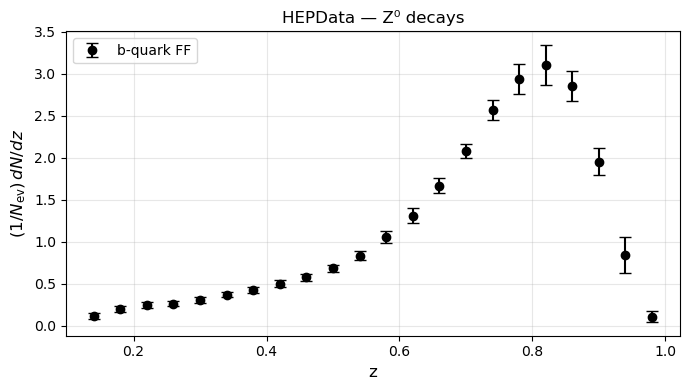

In [2]:
YAML_FILE="Table1.yaml"


def load_hepdata_yaml(filepath):
    """Load the HEPData dataset.
    REturns z_data, y_data, sigma_data.
    """
    with open(filepath, 'r') as f:
        raw = yaml.safe_load(f)

    #momentum fraction z
    indep = raw['independent_variables'][0]
    
    z_data = []
    for pt in indep['values']:
        if 'value' in pt:
            z_data.append(float(pt['value']))
        elif 'low' in pt and 'high' in pt:
            z_data.append(0.5 * (float(pt['low']) + float(pt['high'])))
        else:
            raise ValueError(f"unexpected format: {pt}")
    z_data = np.array(z_data)

    # (1/N) dN/dx
    dep = raw['dependent_variables'][0]

    y_data, sigma_data = [], []
    for pt in dep['values']:
        y_data.append(float(pt['value']))
        err_sq = 0.0
        for err in pt.get('errors', []):
            if 'symerror' in err:
                err_sq += float(err['symerror'])**2
            elif 'asymerror' in err:
                up = abs(float(err['asymerror'].get('plus',  0)))
                dn = abs(float(err['asymerror'].get('minus', 0)))
                err_sq += ((up + dn) / 2.0)**2
        sigma_data.append(max(np.sqrt(err_sq), 1e-6))

    return z_data, np.array(y_data), np.array(sigma_data)

z_data, y_data, sigma_data = load_hepdata_yaml(YAML_FILE)


Z_MIN = max(z_data.min() * 0.5, 1e-4)  
Z_MAX = min(z_data.max() * 1.05, 1)

print(f"\Points: {len(z_data)}   z ∈ [{z_data.min():.3f}, {z_data.max():.3f}]")
print(f"WOrkspace range: [{Z_MIN:.4f}, {Z_MAX:.4f}]")
print(f"\n{'z':>7}  {'(1/N)dN/dz':>12}  {'σ':>10}  {'σ/y [%]':>9}")
print("-" * 46)
for z, y, s in zip(z_data, y_data, sigma_data):
    print(f"{z:7.4f}  {y:12.6f}  {s:10.6f}  {100*s/max(abs(y),1e-9):9.1f}%")

plt.figure(figsize=(7, 4))
plt.errorbar(z_data, y_data, yerr=sigma_data,
             fmt='ko', capsize=4, label='b-quark FF')
plt.xlabel('z', fontsize=12)
plt.ylabel(r'$(1/N_{\rm ev})\,dN/dz$', fontsize=12)
plt.title('HEPData — Z⁰ decays')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


We define our variables that define our phase space and the number of qubits needed

In [ ]:
PARAM_NAMES      = ['N', 'epsilon_b']


PARAM_MIN        = np.array([0.001,  0.001])
PARAM_MAX        = np.array([1.0,   1.0])
N_PARAMS         = 2
QUBITS_PER_PARAM = 5
NUM_QUBITS       = N_PARAMS * QUBITS_PER_PARAM   

print(f"Resolution: 2^{QUBITS_PER_PARAM} = {2**QUBITS_PER_PARAM} values per parameter")
for name, lo, hi in zip(PARAM_NAMES, PARAM_MIN, PARAM_MAX):
    step = (hi - lo) / (2**QUBITS_PER_PARAM-1)
    print(f"  {name:8s}: [{lo:.4f}, {hi:.4f}]   step = {step:.6f}")

def collins_spiller(z, N, epsilon_b):
    """
    Modelo de Collins-Spiller
    Parámetros: N, epsilon_b
    """
    z = np.asarray(z, dtype=float)
    z = np.clip(z, 1e-7, 1.0 - 1e-7)
    
    term1 = (1.0 - z) / z + ((2.0 - z) * epsilon_b) / (1.0 - z)
    term2 = 1.0 + z**2
    denom_inner = 1.0 - 1.0/z - epsilon_b/(1.0 - z)
    denom = denom_inner**2
    
    with np.errstate(divide='ignore', invalid='ignore'):
        val = np.where(np.abs(denom) > 1e-15, N * term1 * term2 / denom, 0.0)
    
    return np.maximum(val, 0.0)


def Peterson(z, N, epsilon_b):
    """
    Modelo de Peterson et al.
    Parámetros: N, epsilon_b
    """
    z = np.asarray(z, dtype=float)
    z = np.clip(z, 1e-7, 1.0 - 1e-7)
    
    denom_inner = 1.0 - 1.0/z - epsilon_b/(1.0 - z)
    denom = z * denom_inner**2
    
    with np.errstate(divide='ignore', invalid='ignore'):
        val = np.where(np.abs(denom) > 1e-15, N / denom, 0.0)
        
    return np.maximum(val, 0.0)


def Kartvelishvili(z, N, alpha_b):
    """
    Modelo empírico de Kartvelishvili
    Parámetros: N, alpha_b
    """
    z = np.asarray(z, dtype=float)
    z = np.clip(z, 1e-7, 1.0 - 1e-7)
    
    val = N * (z**alpha_b) * (1.0 - z)
    return np.maximum(val, 0.0)




def Braaten(z, N, r):
    """
    Modelo de Braaten D_{Q->V} (mesones vectoriales) CORREGIDO
    """
    z = np.asarray(z, dtype=float)
    z = np.clip(z, 1e-7, 1.0 - 1e-7)
    
    term0 = 2.0
    term1 = -2.0 * (3.0 - 2.0*r)
    term2 = 3.0 * (3.0 - 2.0*r + 4.0*(r**2))
    term3 = -2.0 * (1.0 - r) * (4.0 - r + 2.0*(r**2))
    term4 = ((1.0 - r)**2) * (3.0 - 2.0*r + 2.0*(r**2))
    
    poly = term0 + term1*z + term2*(z**2) + term3*(z**3) + term4*(z**4)
    
    numerator = 3.0 * N * r * z * ((1.0 - z)**2) * poly
    denom = (1.0 - (1.0 - r)*z)**6
    
    with np.errstate(divide='ignore', invalid='ignore'):
        val = np.where(np.abs(denom) > 1e-15, numerator / denom, 0.0)
        
    return np.maximum(val, 0.0)


def ff_model(z, theta):
    N, epsilon_b = theta
    if N <= 0 :
        return np.zeros_like(np.asarray(z, dtype=float))
    return Braaten(z, N, epsilon_b)


def chi2_ff(theta):
    """χ²(θ) = Σ [(D̃_modell - y)² / σ²]"""
    f = ff_model(z_data, theta)
    if not np.all(np.isfinite(f)):
        return 1e12
    chi2 = float(np.sum(((f - y_data) / sigma_data)**2))
    return chi2 if np.isfinite(chi2) else 1e12



print("Min values of the parameters (N, r) and the corresponding χ²:")
res = minimize(chi2_ff, x0=[0.5, 0.05],  method='L-BFGS-B')
C_min = res.fun
N_Exact=res.x[0]
r_Exact=res.x[1]
chi2_acceptable = C_min + 2.3 

print(f"Theoretical minimum (C_min): {C_min:.4f}")
print(f"Acceptable threshold: {chi2_acceptable:.4f}")
print(f"Optimal parameters: N = {N_Exact:.4f}, r = {r_Exact:.4f}")


#I put the 3 param models aswell just in order to be able to plot results while the 3param ipynb is running

def peterson_mod(z, N, epsilon, alpha):
    """D(z; N, ε) = N / [z * (1+alpha - 1/z - ε/(1-z))²]
    """
    z = np.asarray(z, dtype=float)
    z = np.clip(z, 1e-7, 1.0 - 1e-7)
    denom_inner = 1.0+ alpha- 1.0/z - epsilon/(1.0 - z)
    denom = z * denom_inner**2
    with np.errstate(divide='ignore', invalid='ignore'):
        val = np.where(np.abs(denom) > 1e-15, N / denom, 0.0)
    return np.maximum(val, 0.0)   # FF is positive


def bowler(z, N, a, b):
    """D(z; N, a, b) = (N / z^(1+b)) * (1-z)^a * e^(-b/z)"""
    z = np.asarray(z, dtype=float)
    z = np.clip(z, 1e-7, 1.0 - 1e-7)
    
    with np.errstate(divide='ignore', invalid='ignore'):
        val = (N / (z**(1.0 + b))) * ((1.0 - z)**a) * np.exp(-b / z)
        val = np.where(np.isfinite(val), val, 0.0)
    return np.maximum(val, 0.0)

def lund(z, N, a, b):
    """D(z; N, a, b) = (N / z) * (1-z)^a * e^(-b/z)"""
    z = np.asarray(z, dtype=float)
    z = np.clip(z, 1e-7, 1.0 - 1e-7)
    
    with np.errstate(divide='ignore', invalid='ignore'):
        val = (N / z) * ((1.0 - z)**a) * np.exp(-b / z)
        val = np.where(np.isfinite(val), val, 0.0)
    return np.maximum(val, 0.0)

def f1(z, N, c, d):
    """D(z; N, c, d) = N * ((1-z)/z) * (1 - c/z - d/(1-z))^-2"""
    z = np.asarray(z, dtype=float)
    z = np.clip(z, 1e-7, 1.0 - 1e-7)
    
    denom_inner = 1.0 - c/z - d/(1.0 - z)
    denom = denom_inner**2
    
    with np.errstate(divide='ignore', invalid='ignore'):
        val = np.where(np.abs(denom) > 1e-15, N * ((1.0 - z) / z) / denom, 0.0)
    return np.maximum(val, 0.0)

def f2(z, N, c, d):
    """D(z; N, c, d) = (N/z) * (1 - c/z - d/(1-z))^-2"""
    z = np.asarray(z, dtype=float)
    z = np.clip(z, 1e-7, 1.0 - 1e-7)
    
    denom_inner = 1.0 - c/z - d/(1.0 - z)
    denom = z * denom_inner**2
    
    with np.errstate(divide='ignore', invalid='ignore'):
        val = np.where(np.abs(denom) > 1e-15, N / denom, 0.0)
    return np.maximum(val, 0.0)

def power_function(z, N, alpha, beta):
    """D(z; N, alpha, beta) = N * z^alpha * (1-z)^beta"""
    z = np.asarray(z, dtype=float)
    z = np.clip(z, 1e-7, 1.0 - 1e-7)
    
    val = N * (z**alpha) * ((1.0 - z)**beta)
    return np.maximum(val, 0.0)






Resolution: 2^5 = 32 values per parameter
  N       : [0.0010, 1.0000]   step = 0.032226
  epsilon_b: [0.0010, 1.0000]   step = 0.032226
Min values of the parameters (N, r) and the corresponding χ²:
Theoretical minimum (C_min): 71.6812
Acceptable threshold: 73.9812
Optimal parameters: N = 0.5100, r = 0.2754


NOISE SIMULATION

In [4]:
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error, thermal_relaxation_error

def get_backend(noise_type=None, noise_level=0.01):
    if noise_type is None:
        return AerSimulator()
        
    noise_model = NoiseModel()
    
    if noise_type == 'depolarizing':
        error_1q = depolarizing_error(noise_level, 1)
        error_2q = depolarizing_error(noise_level * 2, 2) 
        
        noise_model.add_all_qubit_quantum_error(error_1q, ['rx', 'ry', 'rz', 'h', 'u1', 'u2', 'u3'])
        noise_model.add_all_qubit_quantum_error(error_2q, ['cx', 'cz'])
        
    elif noise_type == 'thermal':

        t1 = 50000  
        t2 = 30000  
        
       
        time_1q = 50 * (1 + noise_level * 10) 
        time_cx = 300 * (1 + noise_level * 10)
        
        error_1q = thermal_relaxation_error(t1, t2, time_1q)
        
        error_cx = thermal_relaxation_error(t1, t2, time_cx).expand(thermal_relaxation_error(t1, t2, time_cx))
        
        noise_model.add_all_qubit_quantum_error(error_1q, ['rx', 'ry', 'rz', 'h'])
        noise_model.add_all_qubit_quantum_error(error_cx, ['cx'])

    return AerSimulator(noise_model=noise_model)

QUANTUM OPERATORS

In [5]:
K_ENTANGLED = 5
def initialize_chromosome(num_qubits):
    qc = QuantumCircuit(num_qubits)
    qc.h(range(num_qubits))

    msb_indices = []
    for p in range(N_PARAMS):
        start_idx = p * QUBITS_PER_PARAM
        msb_indices.extend(range(start_idx, start_idx + K_ENTANGLED))

    for i in range(len(msb_indices)):
        for j in range(i + 1, len(msb_indices)):
            qc.cx(msb_indices[i], msb_indices[j])

    qc.barrier()
    return qc


def measure_chromosome(qc, backend):

    qc_m = qc.copy()
    qc_m.measure_all()
    qc_m   = transpile(qc_m, backend)
    counts = backend.run(qc_m, shots=1).result().get_counts()
    return list(counts.keys())[0][::-1]   

def decode_parameters(binary_string):

    max_int = (2 ** QUBITS_PER_PARAM) - 1   
    params  = []
    for k in range(N_PARAMS):
        chunk   = binary_string[k * QUBITS_PER_PARAM : (k + 1) * QUBITS_PER_PARAM]
        int_val = int(chunk, 2)             
        val     = PARAM_MIN[k] + (PARAM_MAX[k] - PARAM_MIN[k]) * (int_val / max_int)
        params.append(val)
    return np.array(params)


def apply_rotation(qc, best_binary, rotation_angle):
    """
      best_bit = 1 → RY(+θ)  (grows P(|1⟩))
      best_bit = 0 → RY(−θ)  (grows P(|0⟩))
    """
    for i in range(qc.num_qubits):
        if i >= len(best_binary):
            continue
        direction = +1 if int(best_binary[i]) == 1 else -1
        qc.ry(direction * rotation_angle, i)

    msb_indices = []
    for p in range(N_PARAMS):
        start_idx = p * QUBITS_PER_PARAM
        msb_indices.extend(range(start_idx, start_idx + K_ENTANGLED))

    for i in range(len(msb_indices)):
        for j in range(i + 1, len(msb_indices)):
            qc.cx(msb_indices[i], msb_indices[j])
            
    return qc


def apply_mutation(qc, mutation_rate):
    
    qc.barrier()
    for i in range(qc.num_qubits):
        if random.random() < mutation_rate:
            qc.x(i)
    return qc

ENTANGLEMENT ANALYSIS

In [6]:
from qiskit.quantum_info import Statevector, partial_trace


def analyze_entanglement_C(population, param_index=0, qubits_per_param=5):

    nonpurities = []
    
    for qc in population:
        state = Statevector(qc)
        
        start_q = param_index * qubits_per_param
        end_q = start_q + qubits_per_param
        param_qubits = list(range(start_q, end_q))
        
        trace_qubits = [q for q in range(qc.num_qubits) if q not in param_qubits]
        rho_reduced = partial_trace(state, trace_qubits)
        
        purity = np.real(rho_reduced.purity())
        C = abs(1.0 - purity)
        nonpurities.append(C)
        
    return np.mean(nonpurities)

QGA RUN FUNCTION

In [7]:
def run_qga(generations=20, population_size=10,
            rotation_angle=0.05, mutation_rate=0.15):
   
    backend    = get_backend(noise_type='none', noise_level=0.01)
    population = [initialize_chromosome(NUM_QUBITS)
                  for _ in range(population_size)]

    best_chi2   = float('inf')
    best_binary = None
    best_theta  = np.array([1.0, 0.006])  
    history     = []
    theta_history = []
    
    stagnation_counter = 0
    current_rot_angle = rotation_angle
    current_mut_rate = mutation_rate

    print(f"QGA ------------------ | {NUM_QUBITS} qubits | "
          f"pop={population_size} | gens={generations}")
    print("=" * 60)

    historial_C_N = []
    historial_C_epsilon_b = []
    
    for gen in range(generations):
        gen_best_chi2   = float('inf')
        gen_best_binary = None
        improved_this_gen = False

        for qc in population:
            binary = measure_chromosome(qc, backend)
            theta  = decode_parameters(binary)
            chi2   = chi2_ff(theta)

            if chi2 < gen_best_chi2:
                gen_best_chi2   = chi2
                gen_best_binary = binary

            if chi2 < best_chi2:
                best_chi2   = chi2
                best_binary = binary
                best_theta  = theta.copy()
                improved_this_gen = True

        history.append(best_chi2)
        theta_history.append(best_theta.copy())
        if improved_this_gen:
            stagnation_counter = 0  
        else:
            stagnation_counter += 1 

        if stagnation_counter >= 4:
            current_mut_rate = min(0.30, current_mut_rate * 1.25)
            
            print(f" [!] Stagnation. Adjusting parameters -> Mutation: {current_mut_rate:.4f}")
            stagnation_counter = 0 

        if gen_best_binary:
            for i in range(len(population)):
                population[i] = apply_rotation(
                    population[i], gen_best_binary, current_rot_angle)
                population[i] = apply_mutation(
                    population[i], current_mut_rate)

        print(f"Gen {gen+1:03d}: χ² = {best_chi2:9.4f}  "
              f"N = {best_theta[0]:.4f}   ε_b = {best_theta[1]:.5f}")


        C_N = analyze_entanglement_C(population, param_index=0, qubits_per_param=QUBITS_PER_PARAM)
        C_epsilon_b = analyze_entanglement_C(population, param_index=1, qubits_per_param=QUBITS_PER_PARAM)
       
    
        historial_C_N.append(C_N)
        historial_C_epsilon_b.append(C_epsilon_b)

    print("=" * 60)
    
    return best_chi2, best_theta, population, history, best_binary, historial_C_N, historial_C_epsilon_b, theta_history


In [27]:
best_chi2, best_theta, pop, history, best_binary, historial_C_N, historial_C_epsilon_b, theta_history_qga = run_qga(
    generations = 20,
    population_size = 10,
    rotation_angle = 0.05,
    mutation_rate = 0.15
)

QGA ------------------ | 10 qubits | pop=10 | gens=20
Gen 001: χ² = 204305.6058  N = 0.0977   ε_b = 0.06545
Gen 002: χ² = 78890.9242  N = 0.3877   ε_b = 0.32326
Gen 003: χ² = 78890.9242  N = 0.3877   ε_b = 0.32326
Gen 004: χ² = 78890.9242  N = 0.3877   ε_b = 0.32326
Gen 005: χ² = 30201.1679  N = 0.1944   ε_b = 0.19435
Gen 006: χ² = 30201.1679  N = 0.1944   ε_b = 0.19435
Gen 007: χ² = 30201.1679  N = 0.1944   ε_b = 0.19435
Gen 008: χ² = 30201.1679  N = 0.1944   ε_b = 0.19435
 [!] Stagnation. Adjusting parameters -> Mutation: 0.1875
Gen 009: χ² = 30201.1679  N = 0.1944   ε_b = 0.19435
Gen 010: χ² = 30201.1679  N = 0.1944   ε_b = 0.19435
Gen 011: χ² = 30201.1679  N = 0.1944   ε_b = 0.19435
Gen 012: χ² = 30201.1679  N = 0.1944   ε_b = 0.19435
 [!] Stagnation. Adjusting parameters -> Mutation: 0.2344
Gen 013: χ² = 30201.1679  N = 0.1944   ε_b = 0.19435
Gen 014: χ² = 30201.1679  N = 0.1944   ε_b = 0.19435
Gen 015: χ² = 30201.1679  N = 0.1944   ε_b = 0.19435
Gen 016: χ² = 30201.1679  N = 0.19


CGA SINGLE RUN FUNCTIONS


In [8]:
def cga_random_individual():
    return ''.join(random.choice('01') for _ in range(NUM_QUBITS))


def cga_tournament_select(population, fitnesses, k=3):
    contestants = random.sample(range(len(population)), k)
    winner = min(contestants, key=lambda i: fitnesses[i])
    return population[winner]


def cga_two_point_crossover(parent_a, parent_b):
    if random.random() > 0.5:
        return parent_a, parent_b
    n = len(parent_a)
    p1, p2 = sorted(random.sample(range(1, n), 2))
    child_a = parent_a[:p1] + parent_b[p1:p2] + parent_a[p2:]
    child_b = parent_b[:p1] + parent_a[p1:p2] + parent_b[p2:]
    return child_a, child_b


def cga_mutate(individual, mutation_rate):
    flipped = []
    for bit in individual:
        if random.random() < mutation_rate:
            flipped.append('1' if bit == '0' else '0')
        else:
            flipped.append(bit)
    return ''.join(flipped)


def run_cga(generations=20, population_size=10, mutation_rate=0.15,
            tournament_k=3, seed=None):
   
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    population = [cga_random_individual() for _ in range(population_size)]

    best_chi2  = float('inf')
    best_theta = np.array([1.0, 0.006, 0.0001])
    history    = []
    theta_history = []

    print(f"CGA --------------- | {NUM_QUBITS} bits | "
          f"pop={population_size} | gens={generations} | "
          f"mut={mutation_rate}")

    for gen in range(generations):

        
        fitnesses = []
        for ind in population:
            theta = decode_parameters(ind)   
            fitnesses.append(chi2_ff(theta))

        
        gen_best_idx = int(np.argmin(fitnesses))
        if fitnesses[gen_best_idx] < best_chi2:
            best_chi2  = fitnesses[gen_best_idx]
            best_theta = decode_parameters(population[gen_best_idx]).copy()
        history.append(best_chi2)
        theta_history.append(best_theta.copy())

        
        elite      = population[gen_best_idx]   
        next_gen   = [elite]

        while len(next_gen) < population_size:
            parent_a = cga_tournament_select(population, fitnesses, tournament_k)
            parent_b = cga_tournament_select(population, fitnesses, tournament_k)
            child_a, child_b = cga_two_point_crossover(parent_a, parent_b)
            next_gen.append(cga_mutate(child_a, mutation_rate))
            if len(next_gen) < population_size:
                next_gen.append(cga_mutate(child_b, mutation_rate))

        population = next_gen

        print(f"Gen {gen+1:03d}: chi2 = {best_chi2:9.4f}  "
              f"N = {best_theta[0]:.4f}   eps = {best_theta[1]:.5f} ")

    print("=" * 60)
    print(f"chi2_CGA  = {best_chi2:.6f}   chi2/n = {best_chi2/len(z_data):.4f}")
    print(f"N         = {best_theta[0]:.6f}")
    print(f"eps       = {best_theta[1]:.6f}")

    return best_chi2, best_theta, history, theta_history


In [29]:
cga_chi2, cga_theta, cga_history, theta_history_cga = run_cga(
    generations     = 20,
    population_size = 10,
    mutation_rate   = 0.03,
    tournament_k    = 3,
)

CGA --------------- | 10 bits | pop=10 | gens=20 | mut=0.03
Gen 001: chi2 = 181382.2864  N = 0.4844   eps = 0.38771 
Gen 002: chi2 = 181382.2864  N = 0.4844   eps = 0.38771 
Gen 003: chi2 = 181382.2864  N = 0.4844   eps = 0.38771 
Gen 004: chi2 = 149580.0147  N = 0.4199   eps = 0.38771 
Gen 005: chi2 = 149580.0147  N = 0.4199   eps = 0.38771 
Gen 006: chi2 = 149580.0147  N = 0.4199   eps = 0.38771 
Gen 007: chi2 = 149580.0147  N = 0.4199   eps = 0.38771 
Gen 008: chi2 = 149580.0147  N = 0.4199   eps = 0.38771 
Gen 009: chi2 = 149580.0147  N = 0.4199   eps = 0.38771 
Gen 010: chi2 = 149580.0147  N = 0.4199   eps = 0.38771 
Gen 011: chi2 = 149580.0147  N = 0.4199   eps = 0.38771 
Gen 012: chi2 = 149580.0147  N = 0.4199   eps = 0.38771 
Gen 013: chi2 = 149580.0147  N = 0.4199   eps = 0.38771 
Gen 014: chi2 = 149580.0147  N = 0.4199   eps = 0.38771 
Gen 015: chi2 = 149580.0147  N = 0.4199   eps = 0.38771 
Gen 016: chi2 = 149580.0147  N = 0.4199   eps = 0.38771 
Gen 017: chi2 = 149580.0147 

DRAW CIRCUIT

In [ ]:
best_qc = pop[0]

print("Final cirquit")
print(f"  gates    : {best_qc.size()}")
print(f"  deep: {best_qc.depth()}")
print(f"  binary chain: {best_binary}")
print(f"  N = {best_theta[0]:.4f}   ε = {best_theta[1]:.5f}")

fig2 = best_qc.draw(output='mpl', style='iqp', fold=40, scale=0.50)
fig2.set_size_inches(100, 75)
plt.tight_layout()
plt.show()


QGA vs CGA (only 1 run)


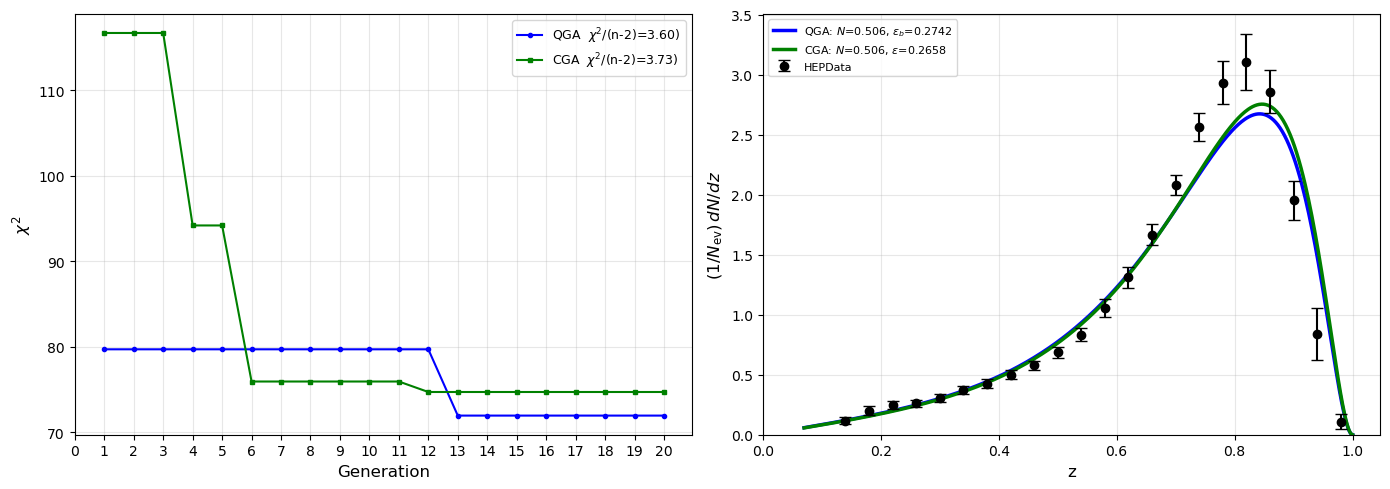


Method              N  epsilon_b       chi2 chi2/n-2
-----------------------------------------------------------------
CGA            0.5065    0.26581    74.6885   3.7344
QGA            0.5065    0.27419    71.9280   3.5964


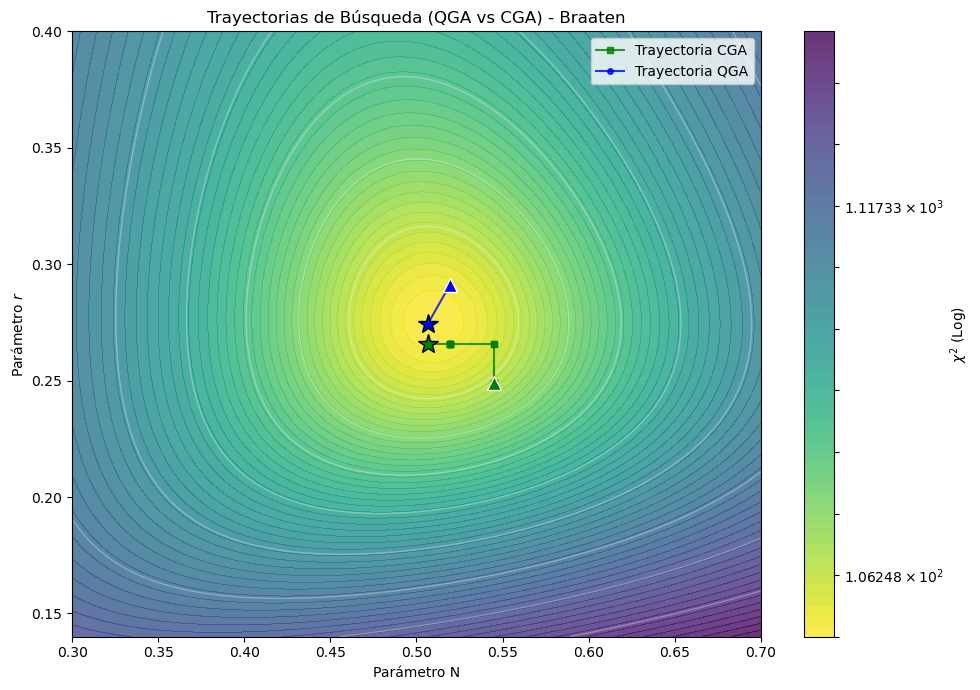

In [ ]:
n_pts = len(z_data)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
gen_axis_qga = np.arange(1, len(history)     + 1)
gen_axis_cga = np.arange(1, len(cga_history) + 1)

axes[0].plot(gen_axis_qga, history,     'b-o', markersize=3, lw=1.5,
             label=f'QGA  $\chi^2$/(n-2)={best_chi2/(n_pts-2):.2f})')
axes[0].plot(gen_axis_cga, cga_history, 'g-s', markersize=3, lw=1.5,
             label=f'CGA  $\chi^2$/(n-2)={cga_chi2/(n_pts-2):.2f})')

axes[0].set_xlabel('Generation', fontsize=12)
axes[0].set_ylabel(r'$\chi^2$', fontsize=12)
valores_x = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20]
axes[0].set_xticks(valores_x)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

z_fine    = np.linspace(Z_MIN, Z_MAX, 500)
f_qga_    = ff_model(z_fine, best_theta)
f_cga_    = ff_model(z_fine, cga_theta)

axes[1].errorbar(z_data, y_data, yerr=sigma_data,
                 fmt='ko', capsize=4, label='HEPData', zorder=5)
axes[1].plot(z_fine, f_qga_, 'b-',  lw=2.5,
             label=(rf'QGA: $N$={best_theta[0]:.3f}, '
                    rf'$\varepsilon_b$={best_theta[1]:.4f}'))
axes[1].plot(z_fine, f_cga_, 'g-',  lw=2.5,
             label=(rf'CGA: $N$={cga_theta[0]:.3f}, '
                    rf'$\varepsilon$={cga_theta[1]:.4f} '))


axes[1].set_xlabel('z', fontsize=12)
axes[1].set_ylabel(r'$(1/N_{\rm ev})\,dN/dz$', fontsize=12)
axes[1].legend(fontsize=8)
axes[1].set_xlim(left=0); axes[1].set_ylim(bottom=0)
axes[1].grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

print("\n" + "=" * 65)
print(f"{'Method':<12} {'N':>8} {'epsilon_b':>10} {'chi2':>10} {'chi2/n-2':>8}")
print("-" * 65)

for label, th, chi2 in [
        ('CGA',       cga_theta,  cga_chi2),
        ('QGA',       best_theta, best_chi2)]:
    print(f"{label:<12} {th[0]:>8.4f} {th[1]:>10.5f} {chi2:>10.4f} {chi2/(n_pts-2):>8.4f}")
print("=" * 65)

MORE QGA VS CGA SINGLE RUN ANALYSIS

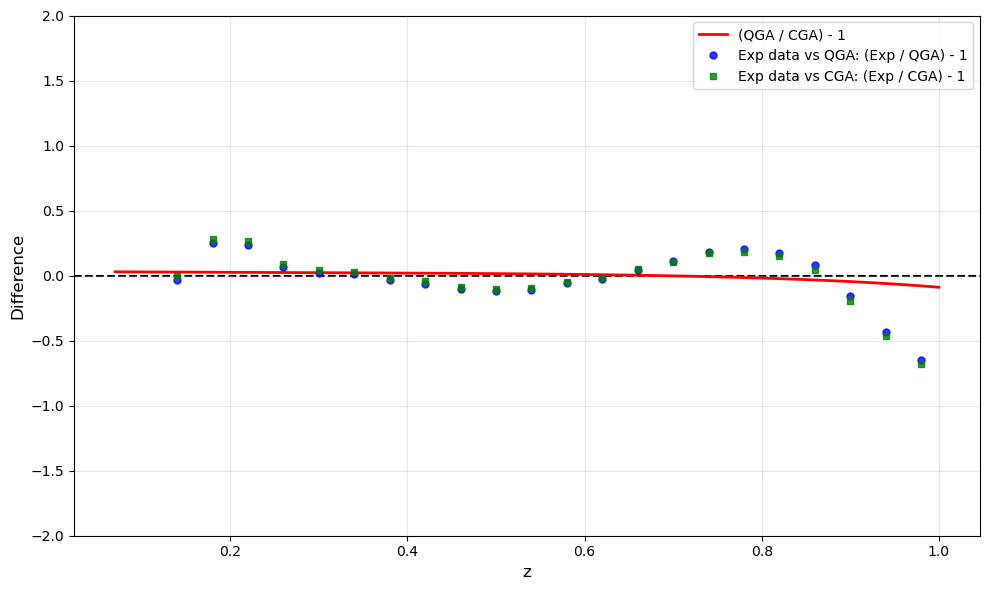

In [103]:
z_fine = np.linspace(Z_MIN, Z_MAX, 500)
f_qga_fine = ff_model(z_fine, best_theta)
f_cga_fine = ff_model(z_fine, cga_theta)

ratio_models = np.divide(f_qga_fine, f_cga_fine, out=np.zeros_like(f_qga_fine), where=(f_cga_fine != 0)) - 1

f_qga_pts = ff_model(z_data, best_theta)
f_cga_pts = ff_model(z_data, cga_theta)

res_qga = np.divide(y_data, f_qga_pts, out=np.zeros_like(y_data), where=(f_qga_pts != 0)) - 1
res_cga = np.divide(y_data, f_cga_pts, out=np.zeros_like(y_data), where=(f_cga_pts != 0)) - 1

plt.figure(figsize=(10, 6))

plt.axhline(0, color='black', linestyle='--', lw=1.5, zorder=1)

plt.plot(z_fine, ratio_models, 'r-', lw=2, label='(QGA / CGA) - 1', zorder=2)

plt.plot(z_data, res_qga, 'bo', markersize=5, alpha=0.8,
         label='Exp data vs QGA: (Exp / QGA) - 1', zorder=3)

plt.plot(z_data, res_cga, 'gs', markersize=5, alpha=0.8,
         label='Exp data vs CGA: (Exp / CGA) - 1', zorder=4)

plt.xlabel('z', fontsize=12)
val_y = [2,1.5,1,0.5,0,-0.5,-1,-1.5,-2]
plt.yticks(val_y)
plt.ylabel('Difference', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

SINGLE RUN ENTANGLEMENT ANALYSIS

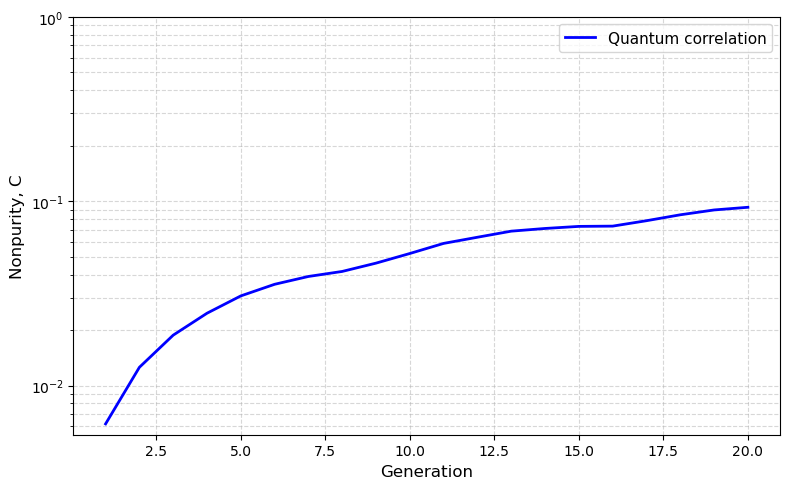

In [104]:
plt.figure(figsize=(8, 5))

generaciones_eje_x = range(1, len(historial_C_N) + 1)

plt.plot(generaciones_eje_x, historial_C_N, label='Quantum correlation', color='blue', lw=2)
    

plt.yscale('log')
valores_y = [10**0, 10**-1, 10**-2]
plt.yticks(valores_y)
plt.xlabel('Generation', fontsize=12)
plt.ylabel('Nonpurity, C', fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

LOOP FOR 100 RUNS PER RANGE AND MODELL

In [ ]:
import pickle
import numpy as np
import os

model_configs = {
    "Braaten": {
        "func": Braaten,
        "ranges": {
            "Big":    {"N": [0.01, 1.0],  "param2": [0.01, 1.0]},
            "Medium": {"N": [0.41, 0.61], "param2": [0.175, 0.375]},
            "Small":  {"N": [0.46, 0.56], "param2": [0.225, 0.325]}
        }
    }
}


current_model_func = None

def ff_model(z, theta):
    N, param2 = theta
    if N <= 0:
        return np.zeros_like(np.asarray(z, dtype=float))
    return current_model_func(z, N, param2)

N_EXECUTIONS = 100

output_dir = "resultados_tfm"
os.makedirs(output_dir, exist_ok=True)

for model_name, config in model_configs.items():
    current_model_func = config["func"]
    
    for range_name, bounds in config["ranges"].items():
        print(f"\n{'='*65}")
        print(f" Initializing {model_name} | Range: {range_name}")
        print(f"{'='*65}")
        

        global PARAM_MIN, PARAM_MAX
        PARAM_MIN = np.array([bounds["N"][0], bounds["param2"][0]])
        PARAM_MAX = np.array([bounds["N"][1], bounds["param2"][1]])
        
        stats_qga = {"best_chi2": [], "best_theta": [], "history": [], "C_N": [], "C_param2": []}
        stats_cga = {"best_chi2": [], "best_theta": [], "history": []}
        
        for i in range(N_EXECUTIONS):
            if (i + 1) % 10 == 0 or i == 0:
                print(f"  -> Ejecución {i+1}/{N_EXECUTIONS} en curso...")
            
            (best_chi2_q, best_theta_q, pop_q, history_q, best_binary_q, 
             hist_C_N, hist_C_eps, theta_hist_q) = run_qga(
                generations=20, population_size=10, rotation_angle=0.05, mutation_rate=0.15
            )
            
            stats_qga["best_chi2"].append(best_chi2_q)
            stats_qga["best_theta"].append(best_theta_q)
            stats_qga["history"].append(history_q)
            stats_qga["C_N"].append(hist_C_N)
            stats_qga["C_param2"].append(hist_C_eps)
            
            cga_chi2, cga_theta, cga_history, theta_history_cga = run_cga(
                generations=20, population_size=10, mutation_rate=0.03, tournament_k=3
            )
            
            stats_cga["best_chi2"].append(cga_chi2)
            stats_cga["best_theta"].append(cga_theta)
            stats_cga["history"].append(cga_history)
        
        filename = f"{output_dir}/resultados_{model_name}_{range_name}.pkl"
        with open(filename, 'wb') as f:
            pickle.dump({'qga': stats_qga, 'cga': stats_cga}, f)
            
        print(f" Finalized {model_name} ({range_name}). File saved: {filename}")

print("\n All model executions have finalized correctly.")


🚀 Iniciando Braaten | Rango: Big
  -> Ejecución 1/100 en curso...
QGA ------------------ | 10 qubits | pop=10 | gens=20
Gen 001: χ² =  239.7323  N = 0.5848   ε_b = 0.32935
Gen 002: χ² =  239.7323  N = 0.5848   ε_b = 0.32935
Gen 003: χ² =  194.3870  N = 0.4252   ε_b = 0.29742
Gen 004: χ² =  194.3870  N = 0.4252   ε_b = 0.29742
Gen 005: χ² =  173.2134  N = 0.5529   ε_b = 0.32935
Gen 006: χ² =  173.2134  N = 0.5529   ε_b = 0.32935
Gen 007: χ² =  173.2134  N = 0.5529   ε_b = 0.32935
Gen 008: χ² =  118.7877  N = 0.4571   ε_b = 0.26548
Gen 009: χ² =  118.7877  N = 0.4571   ε_b = 0.26548
Gen 010: χ² =  118.7877  N = 0.4571   ε_b = 0.26548
Gen 011: χ² =  118.7877  N = 0.4571   ε_b = 0.26548
 [!] Stagnation. Adjusting parameters -> Mutation: 0.1875
Gen 012: χ² =  118.7877  N = 0.4571   ε_b = 0.26548
Gen 013: χ² =  118.7877  N = 0.4571   ε_b = 0.26548
Gen 014: χ² =  118.7877  N = 0.4571   ε_b = 0.26548
Gen 015: χ² =  118.7877  N = 0.4571   ε_b = 0.26548


KeyboardInterrupt: 

GLOBAL FITS (2 AND 3 PARAM)

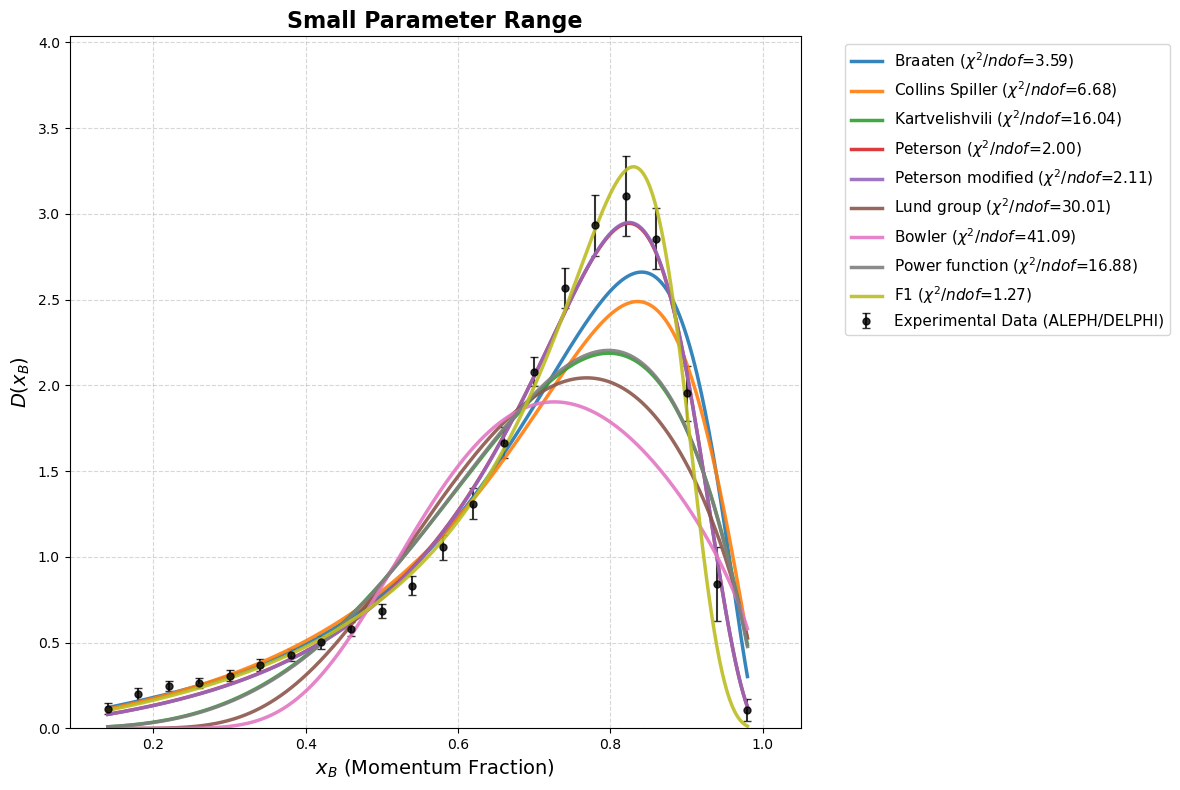

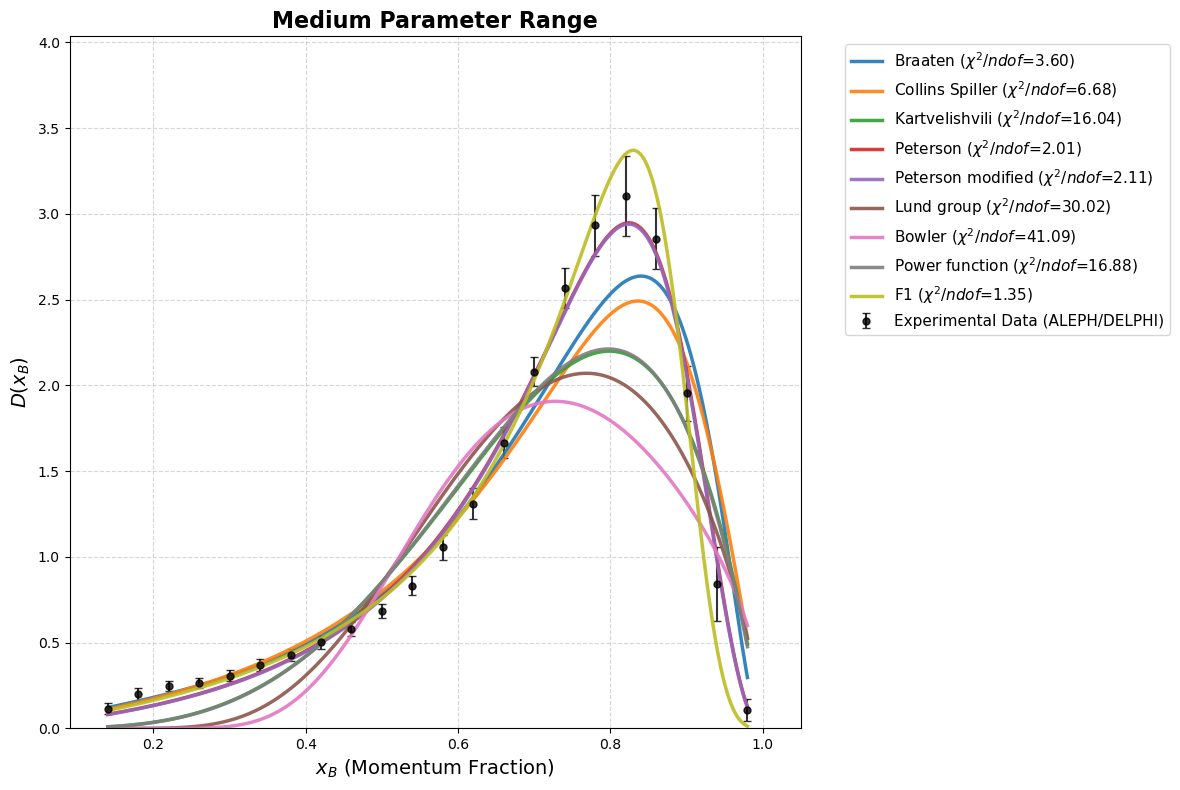

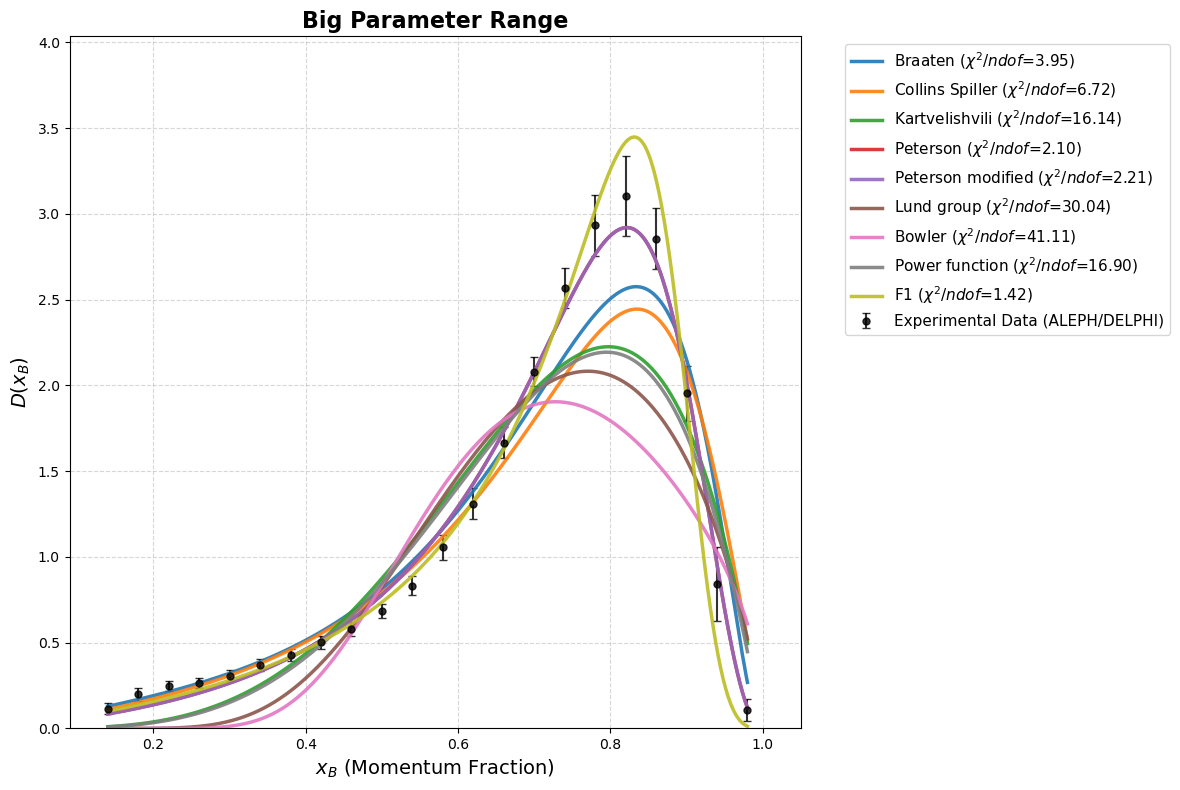

In [ ]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

models_dict = {
    "Braaten": Braaten, 
    "Collins_Spiller": collins_spiller,
    "Kartvelishvili": Kartvelishvili,
    "Peterson": Peterson,
    
    "Peterson_modified": peterson_mod,
    "Lund_group": lund,
    "Bowler": bowler,
    "Power_function": power_function,
    "F1": f1,
    "F2": f2
}

directorios = ["resultados_tfm", "resultados_tfm_3params"]
rangos = ["Small", "Medium", "Big"]

z_plot = np.linspace(min(z_data), max(z_data), 500)


for current_range in rangos:
    plt.figure(figsize=(12, 8))
    
    plt.errorbar(z_data, y_data, yerr=sigma_data, fmt='ko', 
                 markersize=5, capsize=3, alpha=0.8, label='Experimental Data (ALEPH/DELPHI)')
    
    colores = plt.cm.tab10(np.linspace(0, 1, len(models_dict)))
    
    for i, (model_name, model_func) in enumerate(models_dict.items()):
        filepath = None
        
        for d in directorios:
            temp_path = f"{d}/resultados_{model_name}_{current_range}.pkl"
            if os.path.exists(temp_path):
                filepath = temp_path
                break
                
        if filepath is None:
            continue
            
        with open(filepath, 'rb') as f:
            results = pickle.load(f)
            
        
        try:
            if 'qga' in results:
                chi2_array = np.array(results['qga']['best_chi2'])
                best_idx = np.argmin(chi2_array)
                best_chi2_val = chi2_array[best_idx]
                best_theta = results['qga']['best_theta'][best_idx]
                
            elif 'QGA' in results:
                chi2_array = np.array(results['QGA']['chi2'])
                best_idx = np.argmin(chi2_array)
                best_chi2_val = chi2_array[best_idx]
                
                param_keys = [k for k in results['QGA'].keys() 
                              if k not in ['chi2', 'gens_to_target', 'history', 'best_binary'] 
                              and not k.startswith('C_')]
                
                if 'N' in param_keys:
                    param_keys.remove('N')
                    param_keys.insert(0, 'N')
                    
                best_theta = [results['QGA'][k][best_idx] for k in param_keys[:2]]
            else:
                continue
                
        except Exception as e:
            print(f"Error procesando {model_name} ({current_range}): {e}")
            continue
            
        
        ndof = len(z_data) - len(best_theta)
        chi2_ndof = best_chi2_val / ndof
        
        y_fit = model_func(z_plot, *best_theta)
        
        plt.plot(z_plot, y_fit, color=colores[i], linewidth=2.5, alpha=0.9,
                 label=f'{model_name.replace("_", " ")} ($\chi^2/ndof$={chi2_ndof:.2f})')

    plt.title(f'{current_range} Parameter Range', fontsize=16, fontweight='bold')
    plt.xlabel('$x_B$ (Momentum Fraction)', fontsize=14)
    plt.ylabel('$D(x_B)$', fontsize=14)
    
    plt.ylim(0, max(y_data) * 1.3)
    plt.xlim(min(z_data) - 0.05, 1.05)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11, frameon=True)
    plt.tight_layout()
    plt.show()

METRICS AND PLOTS


📊 ANALIZANDO: Braaten | Rango: Small
C_min Teórico: 71.6812 | Umbral Aceptable: 73.9812
[CGA] SP: 100.0% | AR: 0.9989 | Convergencia Media: 2.1 gens
[QGA] SP: 100.0% | AR: 0.9971 | Convergencia Media: 2.5 gens


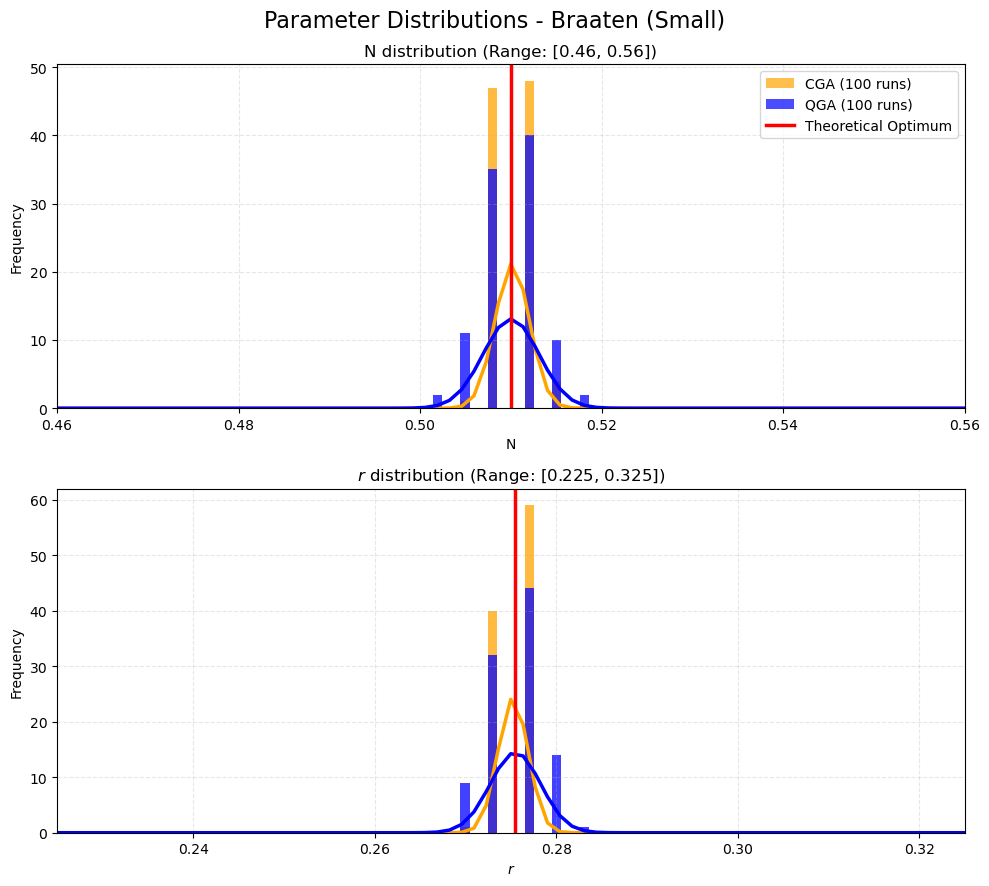


📊 ANALIZANDO: Braaten | Rango: Medium
C_min Teórico: 71.6812 | Umbral Aceptable: 73.9812
[CGA] SP:  99.0% | AR: 0.9991 | Convergencia Media: 4.6 gens
[QGA] SP:  79.0% | AR: 0.9975 | Convergencia Media: 7.1 gens


<Figure size 1000x500 with 0 Axes>

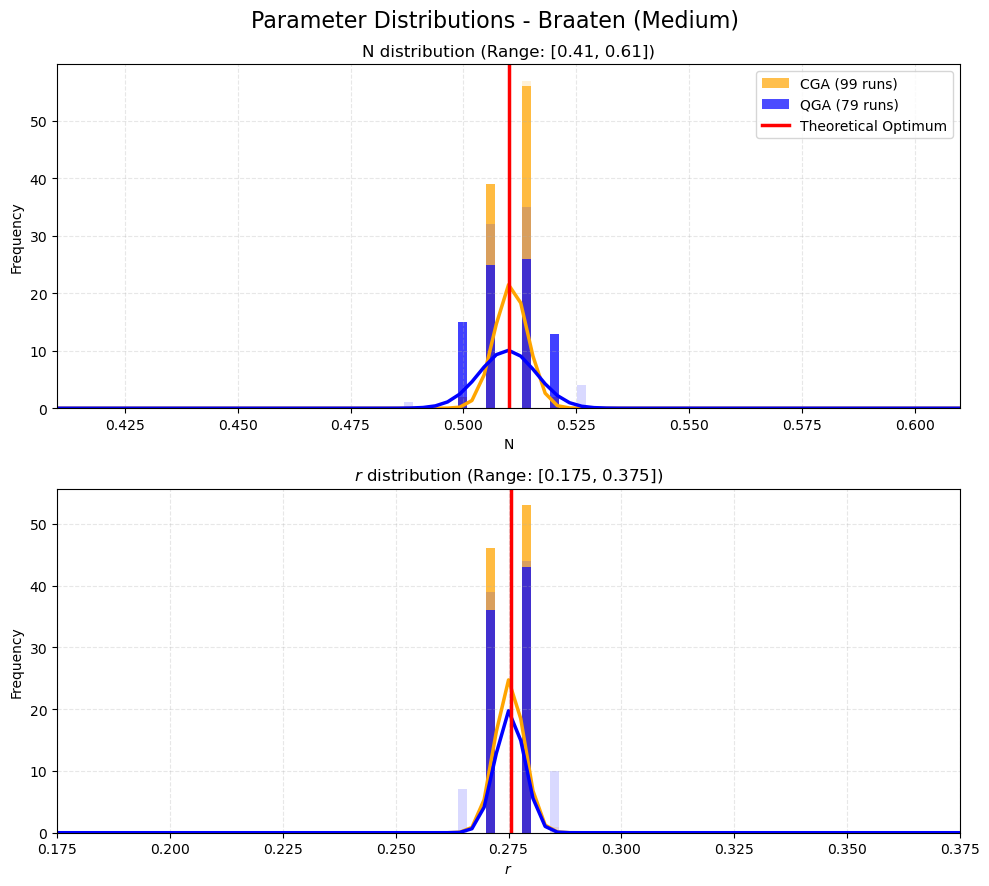


📊 ANALIZANDO: Braaten | Rango: Big
C_min Teórico: 71.6812 | Umbral Aceptable: 73.9812
[CGA] SP:   0.0% | AR: 0.9977 | Convergencia Media: 20.0 gens
[QGA] SP:   0.0% | AR: 0.9959 | Convergencia Media: 20.0 gens


<Figure size 1000x500 with 0 Axes>

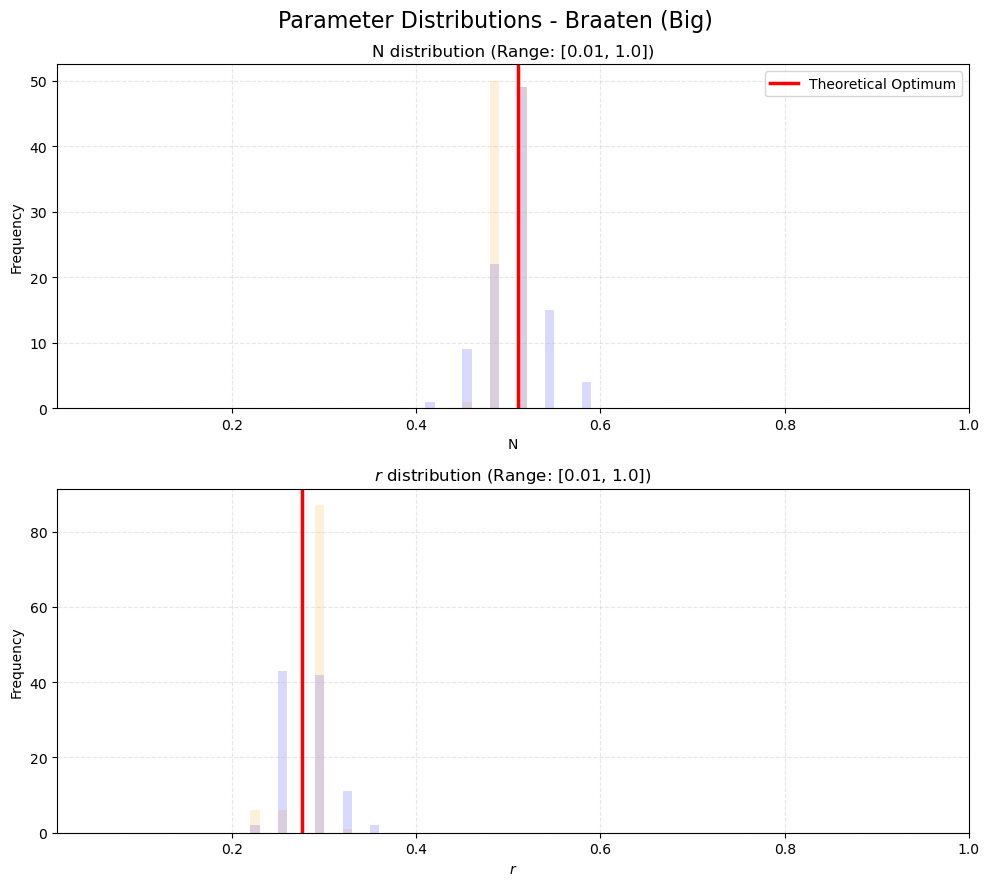


📊 ANALIZANDO: Collins Spiller | Rango: Small
C_min Teórico: 133.6185 | Umbral Aceptable: 135.9185
[CGA] SP: 100.0% | AR: 0.9916 | Convergencia Media: 2.3 gens
[QGA] SP: 100.0% | AR: 0.9951 | Convergencia Media: 1.5 gens


<Figure size 1000x500 with 0 Axes>

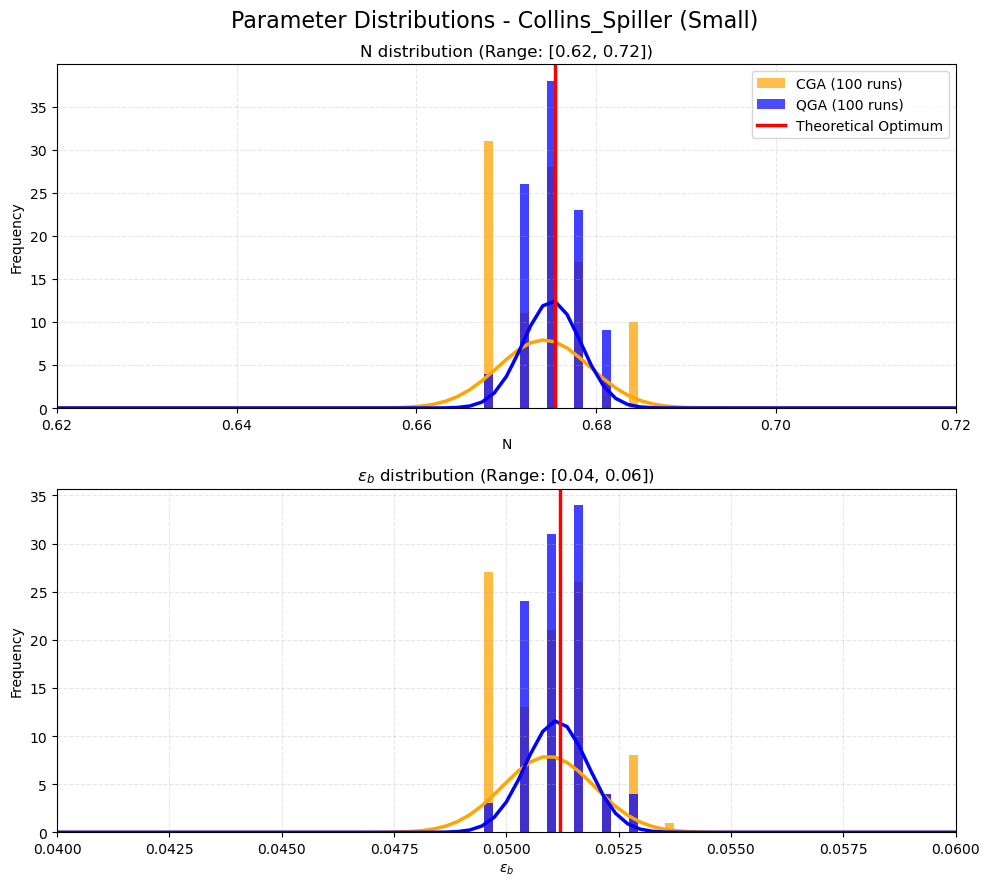


📊 ANALIZANDO: Collins Spiller | Rango: Medium
C_min Teórico: 133.6185 | Umbral Aceptable: 135.9185
[CGA] SP:  94.0% | AR: 0.9941 | Convergencia Media: 6.3 gens
[QGA] SP:  99.0% | AR: 0.9957 | Convergencia Media: 4.6 gens


<Figure size 1000x500 with 0 Axes>

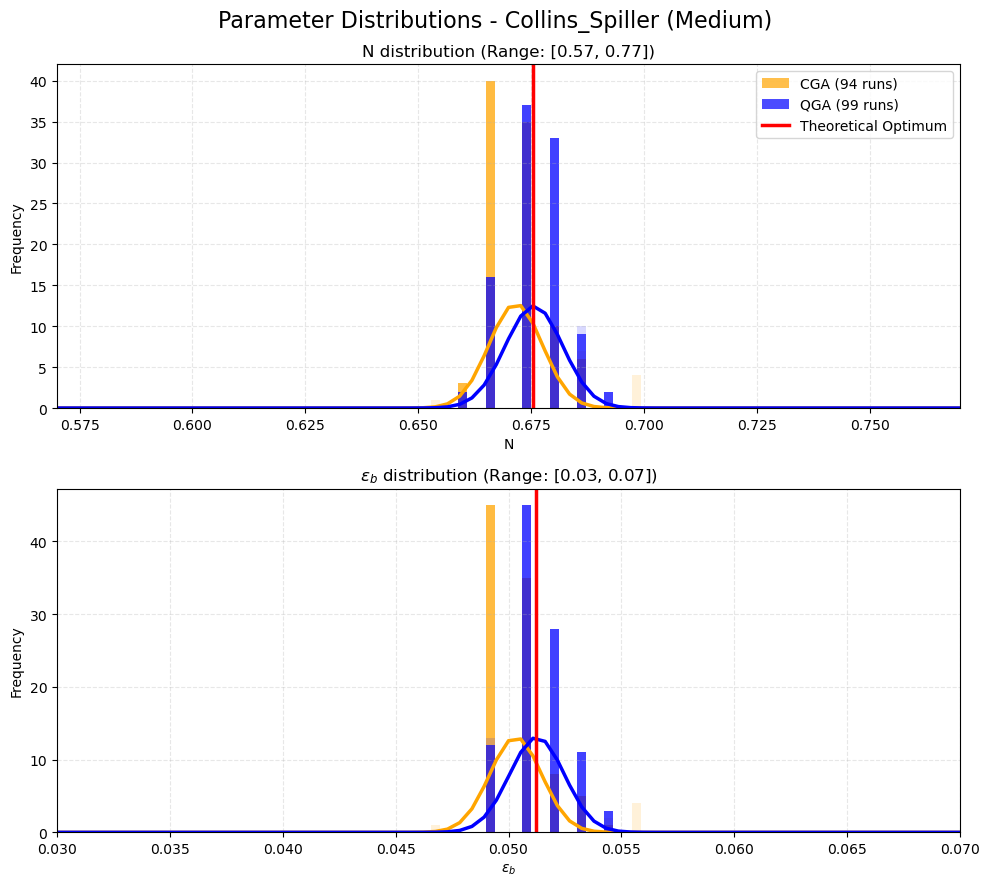


📊 ANALIZANDO: Collins Spiller | Rango: Big
C_min Teórico: 133.6185 | Umbral Aceptable: 135.9185
[CGA] SP:  22.0% | AR: 0.9869 | Convergencia Media: 13.5 gens
[QGA] SP:  13.0% | AR: 0.9961 | Convergencia Media: 11.8 gens


<Figure size 1000x500 with 0 Axes>

KeyboardInterrupt: 

In [ ]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import minimize

models_info = {
    "Braaten": {
        "func": Braaten, "dir": "resultados_tfm", "labels": ['N', r'$r$'],
        "ranges": {
            "Big":    {"min": [0.01, 0.01],  "max": [1.0, 1.0]},
            "Medium": {"min": [0.41, 0.175], "max": [0.61, 0.375]},
            "Small":  {"min": [0.46, 0.225], "max": [0.56, 0.325]}
        }
    },
    "Collins_Spiller": {
        "func": collins_spiller, "dir": "resultados_tfm", "labels": ['N', r'$\epsilon_b$'],
        "ranges": {
            "Big":    {"min": [0.1, 0.0],   "max": [1.2, 0.2]},
            "Medium": {"min": [0.57, 0.03], "max": [0.77, 0.07]},
            "Small":  {"min": [0.62, 0.04], "max": [0.72, 0.06]}
        }
    },
    "Kartvelishvili": {
        "func": Kartvelishvili, "dir": "resultados_tfm", "labels": ['N', r'$\alpha_b$'],
        "ranges": {
            "Big":    {"min": [5.0, 1.0],   "max": [50.0, 8.0]},
            "Medium": {"min": [21.5, 3.0],  "max": [31.5, 5.0]},
            "Small":  {"min": [24.0, 3.5],  "max": [29.0, 4.5]}
        }
    },
    "Peterson": {
        "func": Peterson, "dir": "resultados_tfm", "labels": ['N', r'$\epsilon_b$'],
        "ranges": {
            "Big":    {"min": [0.001, 0.0],    "max": [1.0, 0.3]},
            "Medium": {"min": [0.338, 0.0170], "max": [0.538, 0.0570]},
            "Small":  {"min": [0.388, 0.0270], "max": [0.488, 0.0470]}
        }
    },
    
    "Peterson_modified": {
        "func": peterson_mod, "dir": "resultados_tfm_3params", "labels": ['N', r'$\epsilon_b$', r'$\alpha$'],
        "ranges": {
            "Big":    {"min": [0.001, 0.0, 0.0],      "max": [1.0, 0.3, 0.1]}, 
            "Medium": {"min": [0.338, 0.0170, 0.0],   "max": [0.538, 0.0570, 0.04]},
            "Small":  {"min": [0.388, 0.0270, 0.0],   "max": [0.488, 0.0470, 0.02]}
        }
    },
    "Lund_group": {
        "func": lund, "dir": "resultados_tfm_3params", "labels": ['N', r'$a$', r'$b$'],
        "ranges": {
            "Big":    {"min": [50.0, 0.2, 1.0],   "max": [300.0, 1.5, 5.0]},
            "Medium": {"min": [119.0, 0.66, 2.2], "max": [219.0, 0.86, 3.2]},
            "Small":  {"min": [144.0, 0.71, 2.45],"max": [194.0, 0.81, 2.95]}
        }
    },
    "Bowler": {
        "func": bowler, "dir": "resultados_tfm_3params", "labels": ['N', r'$a$', r'$b$'],
        "ranges": {
            "Big":    {"min": [500.0, 0.1, 2.0],   "max": [2000.0, 1.0, 10.0]},
            "Medium": {"min": [1240.0, 0.36, 4.9], "max": [1440.0, 0.56, 6.9]},
            "Small":  {"min": [1290.0, 0.41, 5.4], "max": [1390.0, 0.51, 6.4]}
        }
    },
    "Power_function": {
        "func": power_function, "dir": "resultados_tfm_3params", "labels": ['N', r'$\alpha$', r'$\beta$'],
        "ranges": {
            "Big":    {"min": [10.0, 2.0, 0.5],  "max": [50.0, 6.0, 1.5]},
            "Medium": {"min": [22.0, 3.5, 0.9],  "max": [33.0, 4.5, 1.15]},
            "Small":  {"min": [25.0, 3.7, 0.95], "max": [30.0, 4.3, 1.10]}
        }
    },
    "F1": {
        "func": f1, "dir": "resultados_tfm_3params", "labels": ['N', r'$c$', r'$d$'],
        "ranges": {
            "Big":    {"min": [0.1, 0.2, 0.0],   "max": [1.0, 1.5, 0.1]},
            "Medium": {"min": [0.38, 0.78, 0.0], "max": [0.58, 0.98, 0.04]},
            "Small":  {"min": [0.43, 0.83, 0.01],"max": [0.53, 0.93, 0.03]}
        }
    },
    "F2": {
        "func": f2, "dir": "resultados_tfm_3params", "labels": ['N', r'$c$', r'$d$'],
        "ranges": {
            "Big":    {"min": [0.1, 0.2, 0.0],    "max": [1.0, 1.5, 0.1]},
            "Medium": {"min": [0.34, 0.90, 0.01], "max": [0.54, 1.10, 0.06]},
            "Small":  {"min": [0.39, 0.95, 0.02], "max": [0.49, 1.05, 0.05]}
        }
    }
}


MAX_GENS = 20
COLORS = {'cga': 'orange', 'qga': 'blue'}

def get_gens_to_target(history_matrix, threshold, max_gens):
    gens_array = []
    for run_hist in history_matrix:
        reached = False
        if not isinstance(run_hist, (list, np.ndarray)) or len(run_hist) == 0:
            gens_array.append(max_gens)
            continue
            
        for gen, val in enumerate(run_hist):
            if val <= threshold:
                gens_array.append(gen + 1)
                reached = True
                break
        if not reached:
            gens_array.append(max_gens)
    return np.array(gens_array)


rangos_a_evaluar = ["Small", "Medium", "Big"]

for model_name, info in models_info.items():
    for current_range in rangos_a_evaluar:
        
        filepath = f"{info['dir']}/resultados_{model_name}_{current_range}.pkl"
        if not os.path.exists(filepath):
            continue 
            
        print(f"\n" + "="*80)
        print(f"{model_name.replace('_', ' ')} | Range: {current_range}")
        print("="*80)
        
        PARAM_MIN = np.array(info["ranges"][current_range]["min"])
        PARAM_MAX = np.array(info["ranges"][current_range]["max"])
        labels = info["labels"]
        num_params = len(PARAM_MIN)
        
        def chi2_dinamico(theta):
            if theta[0] <= 0: return 1e12
            y_fit = info["func"](z_data, *theta)
            chi2 = float(np.sum(((y_fit - y_data) / sigma_data)**2))
            return chi2 if np.isfinite(chi2) else 1e12

        def neg_chi2_dinamico(theta):
            return -chi2_dinamico(theta)
            
        x0_dinamico = (PARAM_MIN + PARAM_MAX) / 2.0
        
        res_min = minimize(chi2_dinamico, x0=x0_dinamico, bounds=list(zip(PARAM_MIN, PARAM_MAX)), method='L-BFGS-B')
        C_min = res_min.fun
        opt_values = res_min.x
        
        res_max = minimize(neg_chi2_dinamico, x0=x0_dinamico, bounds=list(zip(PARAM_MIN, PARAM_MAX)), method='L-BFGS-B')
        C_max = -res_max.fun
        chi2_acceptable = C_min + 2.3 
        
        # 3.2 Carga robusta de los datos
        with open(filepath, 'rb') as f:
            results = pickle.load(f)
            
        extracted_data = {'cga': {}, 'qga': {}}
        
        for algo in ['cga', 'qga']:
            algo_key = algo if algo in results else algo.upper()
            if algo_key not in results: continue
            
            if algo_key in ['qga', 'cga']: 
                extracted_data[algo]['chi2'] = np.array(results[algo_key]['best_chi2'])
                extracted_data[algo]['theta'] = np.array(results[algo_key]['best_theta'])
                extracted_data[algo]['history'] = results[algo_key].get('history', [])
            else: 
                extracted_data[algo]['chi2'] = np.array(results[algo_key]['chi2'])
                
                param_keys = [k for k in results[algo_key].keys() 
                              if k not in ['chi2', 'gens_to_target', 'history', 'best_binary'] 
                              and not k.startswith('C_') and 'historial' not in k]
                if 'N' in param_keys:
                    param_keys.remove('N')
                    param_keys.insert(0, 'N')
                    
                theta_list = []
                n_runs = len(extracted_data[algo]['chi2'])
                for j in range(n_runs):
                    theta_list.append([results[algo_key][k][j] for k in param_keys[:num_params]])
                
                extracted_data[algo]['theta'] = np.array(theta_list)
                extracted_data[algo]['history'] = results[algo_key].get('history', [])
                
                if 'gens_to_target' in results[algo_key]:
                    extracted_data[algo]['gens_to_target'] = results[algo_key]['gens_to_target']

        print(f"C_min Teórico: {C_min:.4f} | Umbral Aceptable: {chi2_acceptable:.4f}")
        
        for algo in ['cga', 'qga']:
            if 'chi2' not in extracted_data[algo]: continue
            
            chi2_array = extracted_data[algo]['chi2']
            n_runs = len(chi2_array)
            
            # Priorizar gens_to_target para los archivos antiguos, sino usar el historial
            if 'gens_to_target' in extracted_data[algo]:
                gens_array = np.array(extracted_data[algo]['gens_to_target'])
            elif len(extracted_data[algo]['history']) > 0:
                gens_array = get_gens_to_target(extracted_data[algo]['history'], chi2_acceptable, MAX_GENS)
            else:
                gens_array = np.full(n_runs, MAX_GENS) # Fallback seguro
            
            success_mask = chi2_array <= chi2_acceptable
            sp = np.sum(success_mask) / n_runs
            avg_gens = np.mean(gens_array[success_mask]) if np.sum(success_mask) > 0 else MAX_GENS
            
            ar_array = np.clip((C_max - chi2_array) / (C_max - C_min), 0, 1)
            mean_ar = np.mean(ar_array)
            
            print(f"[{algo.upper()}] SP: {sp*100:5.1f}% | AR: {mean_ar:.4f} | Convergencia Media: {avg_gens:.1f} gens")

    
        fig, axes = plt.subplots(num_params, 1, figsize=(10, 4.5 * num_params))
        if num_params == 1: axes = [axes] 
        
        for i, p_label in enumerate(labels):
            bines_exactos = np.linspace(PARAM_MIN[i], PARAM_MAX[i], 100)
            
            for algo in ['cga', 'qga']:
                if 'theta' not in extracted_data[algo]: continue
                    
                raw_data_param = extracted_data[algo]['theta'][:, i]
                raw_data_chi2  = extracted_data[algo]['chi2']
                
                mascara_exito = raw_data_chi2 <= chi2_acceptable
                data_filtrada = raw_data_param[mascara_exito]
                n_runs_exito = len(data_filtrada)
                display_algo = algo.upper()
                
                axes[i].hist(raw_data_param, bins=bines_exactos, alpha=0.15, color=COLORS[algo])
                if n_runs_exito == 0: continue
                    
                counts, bins, _ = axes[i].hist(data_filtrada, bins=bines_exactos, alpha=0.7, 
                                               color=COLORS[algo], label=f'{display_algo} ({n_runs_exito} runs)')
                if n_runs_exito > 1:
                    mu, std = norm.fit(data_filtrada)
                    x = np.linspace(PARAM_MIN[i], PARAM_MAX[i], 75)
                    bin_width = bins[1] - bins[0]
                    p_pdf = norm.pdf(x, mu, std) * n_runs_exito * bin_width
                    axes[i].plot(x, p_pdf, color=COLORS[algo], linewidth=2.5)

            axes[i].axvline(opt_values[i], color='red', linestyle='-', linewidth=2.5, label='Theoretical Optimum')
            axes[i].set_xlim(PARAM_MIN[i], PARAM_MAX[i])
            axes[i].set_title(f'{p_label} distribution (Range: [{PARAM_MIN[i]}, {PARAM_MAX[i]}])')
            axes[i].set_ylabel('Frequency')
            axes[i].set_xlabel(p_label)
            axes[i].grid(True, alpha=0.3, linestyle='--')
            if i == 0: axes[i].legend(loc='best')

        plt.suptitle(f'Parameter Distributions - {model_name} ({current_range})', fontsize=16)
        plt.tight_layout()
        plt.show()

       
        plt.figure(figsize=(10, 5))

First attempt entanglement analysis

Recolectando y clasificando datos (separando 2 y 3 parámetros)...
2 Parámetros -> Éxito: 797, Fallo: 403
3 Parámetros -> Éxito: 1007, Fallo: 793


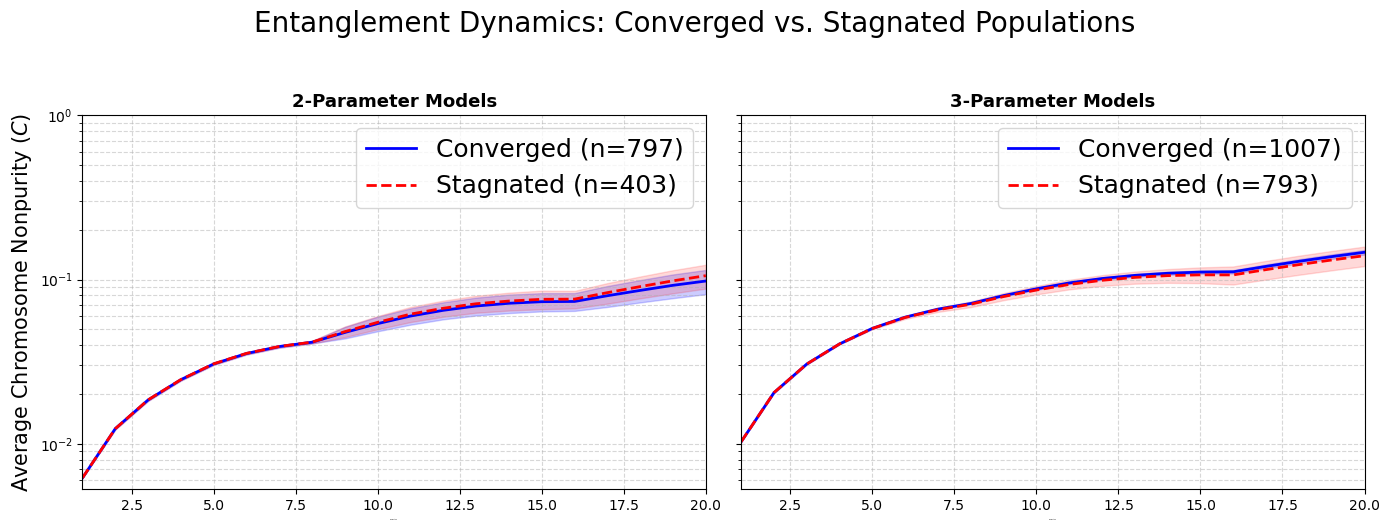

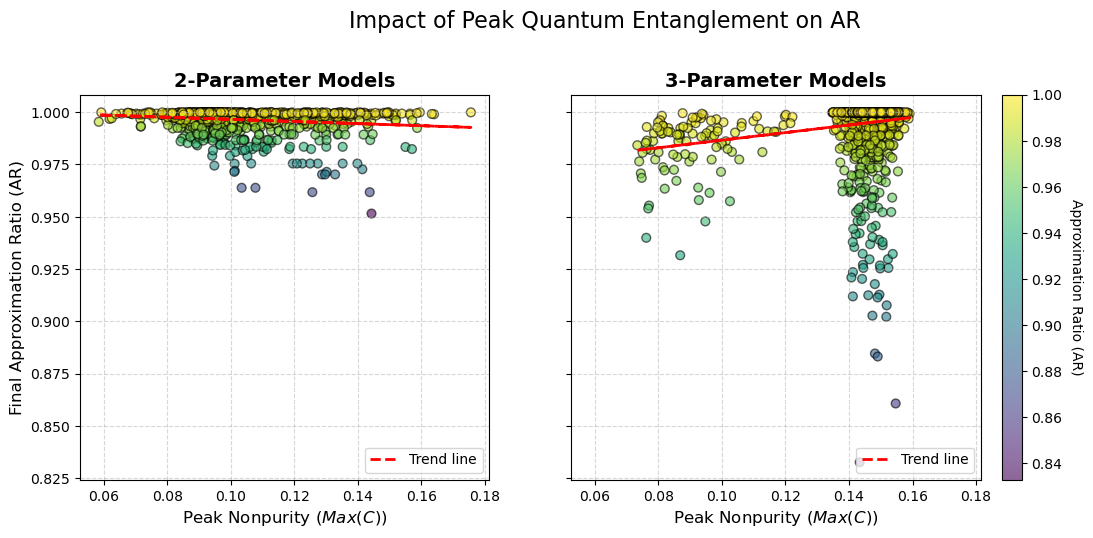

In [ ]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize


data_2p = {'exito': [], 'fallo': [], 'ar': [], 'pico': []}
data_3p = {'exito': [], 'fallo': [], 'ar': [], 'pico': []}



models_info = {
    "Braaten": {
        "func": Braaten, "dir": "resultados_tfm", "labels": ['N', r'$r$'],
        "ranges": {
            "Big":    {"min": [0.01, 0.01],  "max": [1.0, 1.0]},
            "Medium": {"min": [0.41, 0.175], "max": [0.61, 0.375]},
            "Small":  {"min": [0.46, 0.225], "max": [0.56, 0.325]}
        }
    },
    "Collins_Spiller": {
        "func": collins_spiller, "dir": "resultados_tfm", "labels": ['N', r'$\epsilon_b$'],
        "ranges": {
            "Big":    {"min": [0.1, 0.0],   "max": [1.2, 0.2]},
            "Medium": {"min": [0.57, 0.03], "max": [0.77, 0.07]},
            "Small":  {"min": [0.62, 0.04], "max": [0.72, 0.06]}
        }
    },
    "Kartvelishvili": {
        "func": Kartvelishvili, "dir": "resultados_tfm", "labels": ['N', r'$\alpha_b$'],
        "ranges": {
            "Big":    {"min": [5.0, 1.0],   "max": [50.0, 8.0]},
            "Medium": {"min": [21.5, 3.0],  "max": [31.5, 5.0]},
            "Small":  {"min": [24.0, 3.5],  "max": [29.0, 4.5]}
        }
    },
    "Peterson": {
        "func": Peterson, "dir": "resultados_tfm", "labels": ['N', r'$\epsilon_b$'],
        "ranges": {
            "Big":    {"min": [0.001, 0.0],    "max": [1.0, 0.3]},
            "Medium": {"min": [0.338, 0.0170], "max": [0.538, 0.0570]},
            "Small":  {"min": [0.388, 0.0270], "max": [0.488, 0.0470]}
        }
    },
    
    "Peterson_modified": {
        "func": peterson_mod, "dir": "resultados_tfm_3params", "labels": ['N', r'$\epsilon_b$', r'$\alpha$'],
        "ranges": {
            "Big":    {"min": [0.001, 0.0, 0.0],      "max": [1.0, 0.3, 0.1]}, 
            "Medium": {"min": [0.338, 0.0170, 0.0],   "max": [0.538, 0.0570, 0.04]},
            "Small":  {"min": [0.388, 0.0270, 0.0],   "max": [0.488, 0.0470, 0.02]}
        }
    },
    "Lund_group": {
        "func": lund, "dir": "resultados_tfm_3params", "labels": ['N', r'$a$', r'$b$'],
        "ranges": {
            "Big":    {"min": [50.0, 0.2, 1.0],   "max": [300.0, 1.5, 5.0]},
            "Medium": {"min": [119.0, 0.66, 2.2], "max": [219.0, 0.86, 3.2]},
            "Small":  {"min": [144.0, 0.71, 2.45],"max": [194.0, 0.81, 2.95]}
        }
    },
    "Bowler": {
        "func": bowler, "dir": "resultados_tfm_3params", "labels": ['N', r'$a$', r'$b$'],
        "ranges": {
            "Big":    {"min": [500.0, 0.1, 2.0],   "max": [2000.0, 1.0, 10.0]},
            "Medium": {"min": [1240.0, 0.36, 4.9], "max": [1440.0, 0.56, 6.9]},
            "Small":  {"min": [1290.0, 0.41, 5.4], "max": [1390.0, 0.51, 6.4]}
        }
    },
    "Power_function": {
        "func": power_function, "dir": "resultados_tfm_3params", "labels": ['N', r'$\alpha$', r'$\beta$'],
        "ranges": {
            "Big":    {"min": [10.0, 2.0, 0.5],  "max": [50.0, 6.0, 1.5]},
            "Medium": {"min": [22.0, 3.5, 0.9],  "max": [33.0, 4.5, 1.15]},
            "Small":  {"min": [25.0, 3.7, 0.95], "max": [30.0, 4.3, 1.10]}
        }
    },
    "F1": {
        "func": f1, "dir": "resultados_tfm_3params", "labels": ['N', r'$c$', r'$d$'],
        "ranges": {
            "Big":    {"min": [0.1, 0.2, 0.0],   "max": [1.0, 1.5, 0.1]},
            "Medium": {"min": [0.38, 0.78, 0.0], "max": [0.58, 0.98, 0.04]},
            "Small":  {"min": [0.43, 0.83, 0.01],"max": [0.53, 0.93, 0.03]}
        }
    },
    "F2": {
        "func": f2, "dir": "resultados_tfm_3params", "labels": ['N', r'$c$', r'$d$'],
        "ranges": {
            "Big":    {"min": [0.1, 0.2, 0.0],    "max": [1.0, 1.5, 0.1]},
            "Medium": {"min": [0.34, 0.90, 0.01], "max": [0.54, 1.10, 0.06]},
            "Small":  {"min": [0.39, 0.95, 0.02], "max": [0.49, 1.05, 0.05]}
        }
    }
}

MAX_GENS = 20


for model_name, info in models_info.items():
    for current_range in ["Small", "Medium", "Big"]:
        filepath = f"{info['dir']}/resultados_{model_name}_{current_range}.pkl"
        if not os.path.exists(filepath): continue
            
        PARAM_MIN = np.array(info["ranges"][current_range]["min"])
        PARAM_MAX = np.array(info["ranges"][current_range]["max"])
        num_params = len(PARAM_MIN)
        
        target_dict = data_2p if num_params == 2 else data_3p
        
        def chi2_dinamico(theta):
            if theta[0] <= 0: return 1e12
            y_fit = info["func"](z_data, *theta)
            chi2 = float(np.sum(((y_fit - y_data) / sigma_data)**2))
            return chi2 if np.isfinite(chi2) else 1e12

        x0_dinamico = (PARAM_MIN + PARAM_MAX) / 2.0
        res_min = minimize(chi2_dinamico, x0=x0_dinamico, bounds=list(zip(PARAM_MIN, PARAM_MAX)), method='L-BFGS-B')
        C_min = res_min.fun
        
        res_max = minimize(lambda t: -chi2_dinamico(t), x0=x0_dinamico, bounds=list(zip(PARAM_MIN, PARAM_MAX)), method='L-BFGS-B')
        C_max = -res_max.fun
        chi2_acceptable = C_min + 2.3 if num_params == 2 else C_min + 3.53 

        with open(filepath, 'rb') as f:
            results = pickle.load(f)
            
        qga_data = results.get('qga', results.get('QGA', {}))
        if not qga_data: continue
            
        chi2_finales = qga_data.get('best_chi2', qga_data.get('chi2', []))
        if len(chi2_finales) == 0: continue
            
        claves_C = [k for k in qga_data.keys() if ('C_' in k or 'c_' in k.lower() or 'historial' in k.lower()) 
                    and k not in ['chi2', 'gens_to_target', 'history', 'best_binary', 'best_theta']
                    and isinstance(qga_data[k], (list, np.ndarray)) and len(qga_data[k]) > 0]
        
        if not claves_C: continue
            
        n_runs = len(chi2_finales)
        
        for run_idx in range(n_runs):
            run_chi2 = chi2_finales[run_idx]
            run_ar = np.clip((C_max - run_chi2) / (C_max - C_min), 0, 1)
            
            entrelazamiento_cromosoma = []
            
            for clave in claves_C:
                run_C_history = qga_data[clave][run_idx]
                
                # Padding si la ejecución convergió pronto
                if isinstance(run_C_history, (list, np.ndarray)):
                    run_C_arr = list(run_C_history)
                    if 0 < len(run_C_arr) < MAX_GENS:
                        run_C_arr.extend([run_C_arr[-1]] * (MAX_GENS - len(run_C_arr)))
                    elif len(run_C_arr) == 0:
                        run_C_arr = [0.0] * MAX_GENS
                    entrelazamiento_cromosoma.append(run_C_arr[:MAX_GENS])
            
            if not entrelazamiento_cromosoma: continue
                
            media_run_C = np.mean(entrelazamiento_cromosoma, axis=0)
            pico_C = np.max(media_run_C)
            
            target_dict['ar'].append(run_ar)
            target_dict['pico'].append(pico_C)
            
            if run_chi2 <= chi2_acceptable:
                target_dict['exito'].append(media_run_C)
            else:
                target_dict['fallo'].append(media_run_C)

print(f"2 Parámetros -> Éxito: {len(data_2p['exito'])}, Fallo: {len(data_2p['fallo'])}")
print(f"3 Parámetros -> Éxito: {len(data_3p['exito'])}, Fallo: {len(data_3p['fallo'])}")


fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
generaciones = np.arange(1, MAX_GENS + 1)
titulos = ["2-Parameter Models", "3-Parameter Models"]
datos_grafico = [data_2p, data_3p]

for idx, ax in enumerate(axes):
    dict_actual = datos_grafico[idx]
    
    if dict_actual['exito']:
        matriz_exito = np.array(dict_actual['exito'])
        mean_exito = np.mean(matriz_exito, axis=0)
        std_exito = np.std(matriz_exito, axis=0)
        ax.plot(generaciones, mean_exito, color='blue', lw=2, label=f'Converged (n={len(dict_actual["exito"])})')
        ax.fill_between(generaciones, np.maximum(1e-6, mean_exito - std_exito), mean_exito + std_exito, color='blue', alpha=0.2)

    if dict_actual['fallo']:
        matriz_fallo = np.array(dict_actual['fallo'])
        mean_fallo = np.mean(matriz_fallo, axis=0)
        std_fallo = np.std(matriz_fallo, axis=0)
        ax.plot(generaciones, mean_fallo, color='red', lw=2, linestyle='--', label=f'Stagnated (n={len(dict_actual["fallo"])})')
        ax.fill_between(generaciones, np.maximum(1e-6, mean_fallo - std_fallo), mean_fallo + std_fallo, color='red', alpha=0.15)

    ax.set_yscale('log')
    valores_y = [10**0, 10**-1, 10**-2]
    ax.set_yticks(valores_y)
    ax.set_title(titulos[idx], fontsize=13, fontweight='bold')
    ax.set_xlabel('Generation', fontsize=1)
    if idx == 0: ax.set_ylabel('Average Chromosome Nonpurity ($C$)', fontsize=15)
    ax.grid(True, which="both", ls="--", alpha=0.5)
    ax.legend(fontsize=18)
    ax.set_xlim(1, MAX_GENS)

plt.suptitle('Entanglement Dynamics: Converged vs. Stagnated Populations', fontsize=20, y=1.05)
plt.tight_layout()
plt.show()



Entanglement analysis attempt 2

✅ Ejecuciones 2P cargadas: 600
✅ Ejecuciones 3P cargadas: 1500


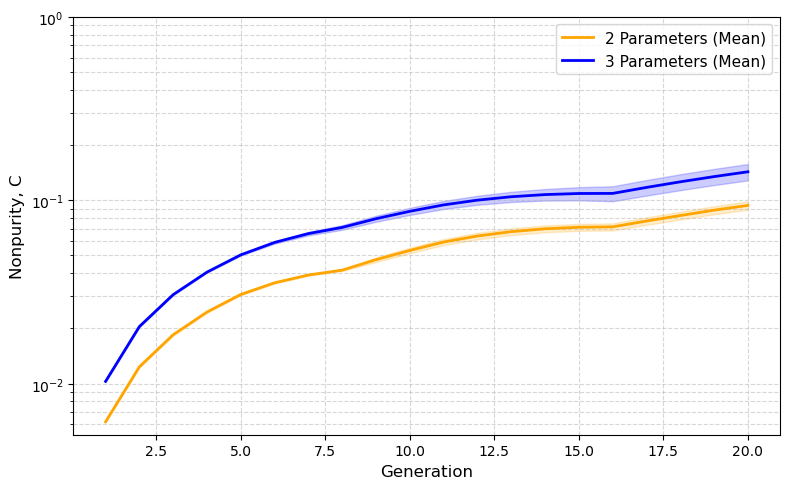

In [ ]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

def cargar_y_agregar_non_purity(directorio, n_params):
    historiales_globales = []
    
    if not os.path.exists(directorio):
        print(f" error '{directorio}' .")
        return np.array([])

    for filename in os.listdir(directorio):
        if filename.endswith(".pkl"):
            filepath = os.path.join(directorio, filename)
            with open(filepath, 'rb') as f:
                datos = pickle.load(f)
                qga_data = datos.get('qga', {})
                
                if n_params == 2:
                    if "C_N" not in qga_data or "C_param2" not in qga_data:
                        continue 
                    
                    n_executions = len(qga_data["C_N"])
                    for i in range(n_executions):
                        c1 = np.array(qga_data["C_N"][i])
                        c2 = np.array(qga_data["C_param2"][i])
                        c_global = (c1 + c2) / 2.0
                        historiales_globales.append(c_global)
                
                elif n_params == 3:
                    if "C_p1" not in qga_data:
                        continue 
                    
                    n_executions = len(qga_data["C_p1"])
                    for i in range(n_executions):
                        c1 = np.array(qga_data["C_p1"][i])
                        c2 = np.array(qga_data["C_p2"][i])
                        c3 = np.array(qga_data["C_p3"][i])
                        c_global = (c1 + c2 + c3) / 3.0
                        historiales_globales.append(c_global)
                        
    return np.array(historiales_globales)

datos_2p = cargar_y_agregar_non_purity("resultados_tfm", n_params=2)
datos_3p = cargar_y_agregar_non_purity("resultados_tfm_3params", n_params=3)

print(f"2p: {len(datos_2p)}")
print(f"3p: {len(datos_3p)}")

plt.figure(figsize=(8, 5))

if datos_2p.size > 0:
    media_2p = np.mean(datos_2p, axis=0)
    std_2p = np.std(datos_2p, axis=0)
    generaciones_x_2p = range(1, len(media_2p) + 1)
    
    plt.plot(generaciones_x_2p, media_2p, label='2 Parameters (Mean)', color='orange', lw=2)
    plt.fill_between(generaciones_x_2p, 
                     np.clip(media_2p - std_2p, a_min=1e-5, a_max=None), 
                     media_2p + std_2p, color='orange', alpha=0.2)

if datos_3p.size > 0:
    media_3p = np.mean(datos_3p, axis=0)
    std_3p = np.std(datos_3p, axis=0)
    generaciones_x_3p = range(1, len(media_3p) + 1)
    
    plt.plot(generaciones_x_3p, media_3p, label='3 Parameters (Mean)', color='blue', lw=2)
    plt.fill_between(generaciones_x_3p, 
                     np.clip(media_3p - std_3p, a_min=1e-5, a_max=None), 
                     media_3p + std_3p, color='blue', alpha=0.2)

plt.yscale('log')
valores_y = [10**0, 10**-1, 10**-2]
plt.yticks(valores_y)
plt.xlabel('Generation', fontsize=12)
plt.ylabel('Nonpurity, C', fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

More entanglement analysis attempts 

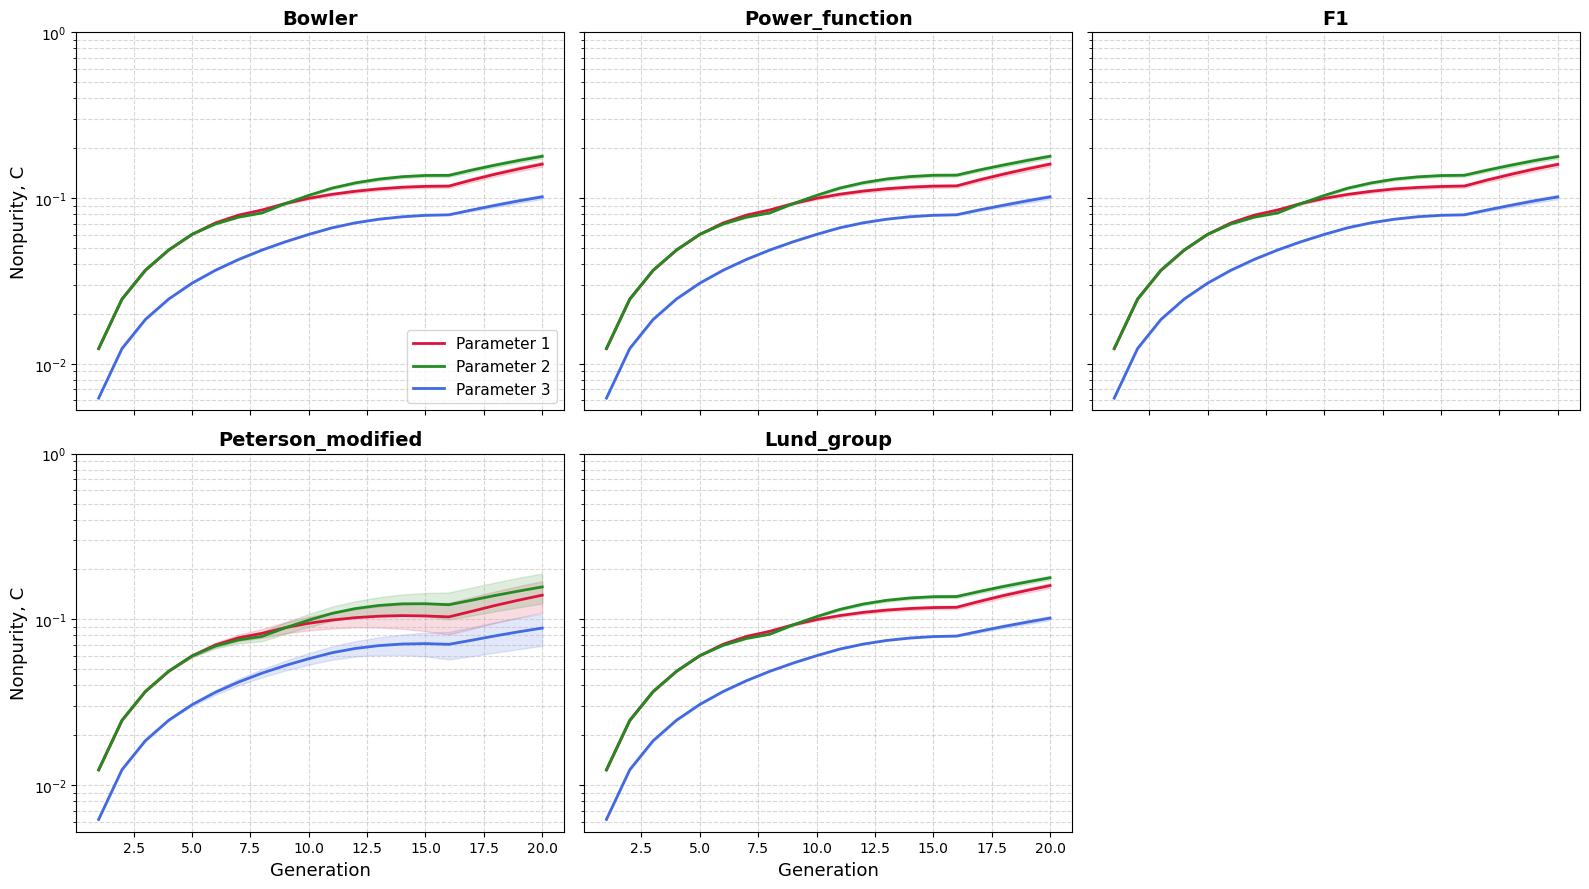

In [ ]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

directorio_3p = "resultados_tfm_3params"

modelos_data = {}

if os.path.exists(directorio_3p):
    for filename in os.listdir(directorio_3p):
        if filename.endswith(".pkl"):
            
            partes = filename.replace(".pkl", "").split("_")
            
            if len(partes) >= 3:
                
                rango = partes[-1]
                modelo = "_".join(partes[1:-1]) 
                
                if modelo not in modelos_data:
                    modelos_data[modelo] = {"C_p1": [], "C_p2": [], "C_p3": []}
                    
                filepath = os.path.join(directorio_3p, filename)
                with open(filepath, 'rb') as f:
                    datos = pickle.load(f)
                    qga_data = datos.get('qga', {})
                    
                    if "C_p1" in qga_data:
                        modelos_data[modelo]["C_p1"].extend(qga_data["C_p1"])
                        modelos_data[modelo]["C_p2"].extend(qga_data["C_p2"])
                        modelos_data[modelo]["C_p3"].extend(qga_data["C_p3"])
else:
    print(f" No se encuentra el directorio: {directorio_3p}")

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 9), sharex=True, sharey=True)
axes = axes.flatten() 
colores = ['crimson', 'forestgreen', 'royalblue']
etiquetas = ['Parameter 1', 'Parameter 2', 'Parameter 3']

for idx, (modelo, dict_datos) in enumerate(modelos_data.items()):
    if idx >= 6: 
        break
        
    ax = axes[idx]
    
    
    c1_array = np.array(dict_datos["C_p1"])
    c2_array = np.array(dict_datos["C_p2"])
    c3_array = np.array(dict_datos["C_p3"])
    
    if c1_array.size == 0:
        ax.set_title(f"{modelo} (Sin datos)")
        continue

    media_c1 = np.mean(c1_array, axis=0)
    media_c2 = np.mean(c2_array, axis=0)
    media_c3 = np.mean(c3_array, axis=0)
    
    std_c1 = np.std(c1_array, axis=0)
    std_c2 = np.std(c2_array, axis=0)
    std_c3 = np.std(c3_array, axis=0)
    
    generaciones = range(1, len(media_c1) + 1)
    
    ax.plot(generaciones, media_c1, label=etiquetas[0], color=colores[0], lw=2)
    ax.plot(generaciones, media_c2, label=etiquetas[1], color=colores[1], lw=2)
    ax.plot(generaciones, media_c3, label=etiquetas[2], color=colores[2], lw=2)
    
    ax.fill_between(generaciones, np.clip(media_c1 - std_c1, 1e-5, None), media_c1 + std_c1, color=colores[0], alpha=0.15)
    ax.fill_between(generaciones, np.clip(media_c2 - std_c2, 1e-5, None), media_c2 + std_c2, color=colores[1], alpha=0.15)
    ax.fill_between(generaciones, np.clip(media_c3 - std_c3, 1e-5, None), media_c3 + std_c3, color=colores[2], alpha=0.15)
    
    ax.set_title(modelo, fontsize=14, fontweight='bold')
    ax.set_yscale('log')
    ax.set_yticks([10**0, 10**-1, 10**-2])
    ax.grid(True, which="both", ls="--", alpha=0.5)
    
    if idx == 0:
        ax.legend(fontsize=11, loc='lower right')

for j in range(idx + 1, 6):
    fig.delaxes(axes[j])

for ax in axes[-3:]: 
    if ax.get_subplotspec().is_last_row():
        ax.set_xlabel('Generation', fontsize=13)
        
for ax in axes[[0, 3]]:
    ax.set_ylabel('Nonpurity, C', fontsize=13)

plt.tight_layout()
plt.show()

Now by range

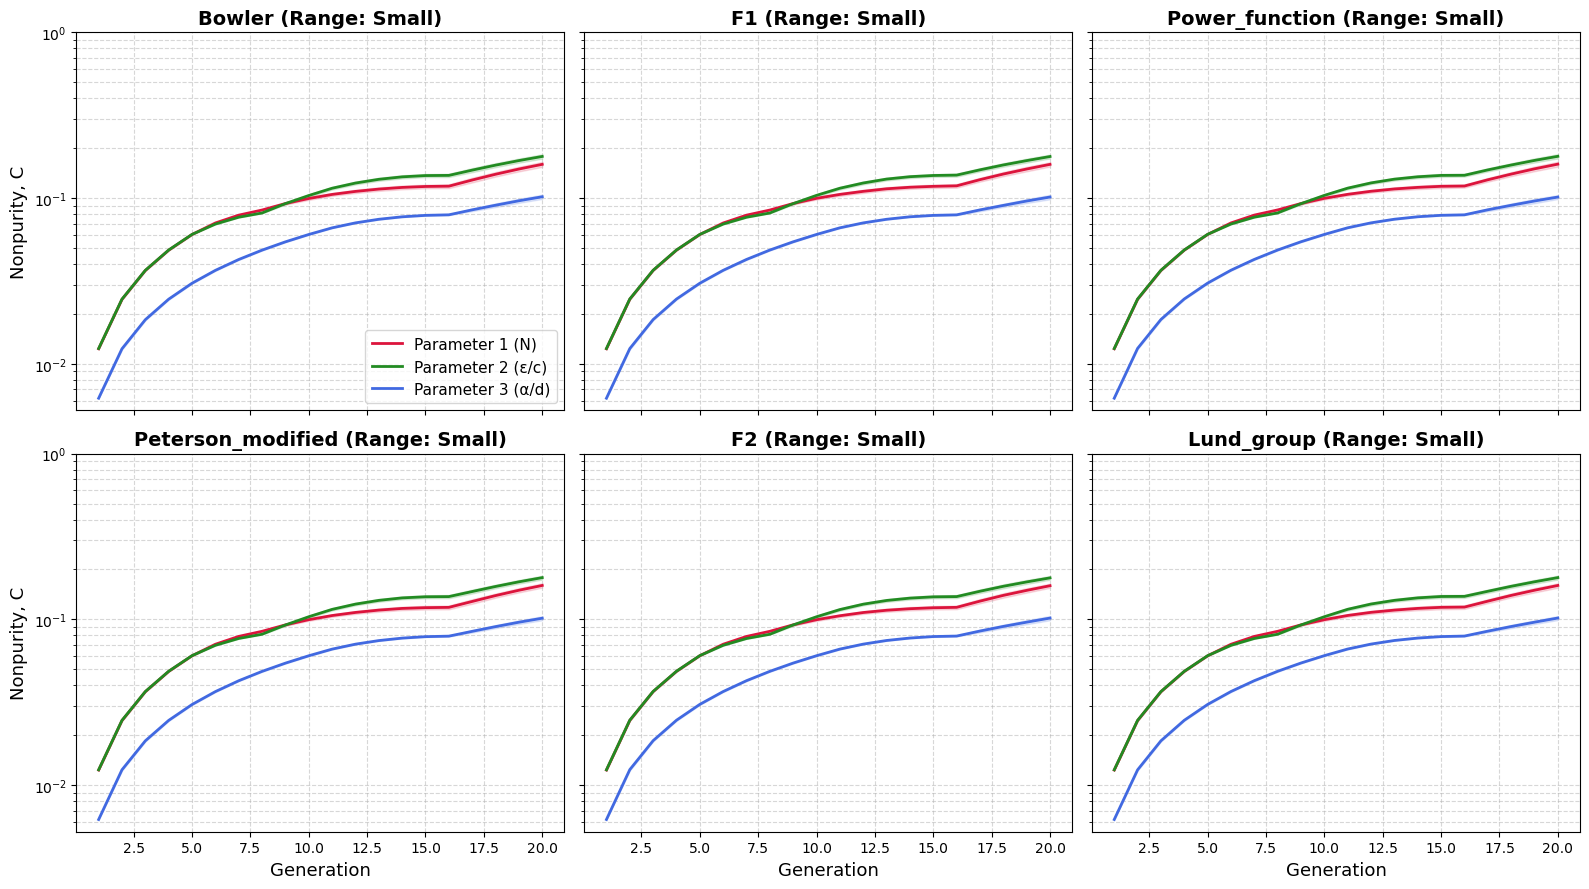

In [ ]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

directorio_3p = "resultados_tfm_3params"

modelos_data = {}
rango_objetivo = "Small"  

if os.path.exists(directorio_3p):
    for filename in os.listdir(directorio_3p):
        if filename.endswith(".pkl") and rango_objetivo in filename:
            partes = filename.replace(".pkl", "").split("_")
            
            if len(partes) >= 3:
                modelo = "_".join(partes[1:-1]) 
                
                if modelo not in modelos_data:
                    modelos_data[modelo] = {"C_p1": [], "C_p2": [], "C_p3": []}
                    
                filepath = os.path.join(directorio_3p, filename)
                with open(filepath, 'rb') as f:
                    datos = pickle.load(f)
                    qga_data = datos.get('qga', {})
                    
                    if "C_p1" in qga_data:
                        modelos_data[modelo]["C_p1"].extend(qga_data["C_p1"])
                        modelos_data[modelo]["C_p2"].extend(qga_data["C_p2"])
                        modelos_data[modelo]["C_p3"].extend(qga_data["C_p3"])
else:
    print(f" No se encuentra el directorio: {directorio_3p}")

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 9), sharex=True, sharey=True)
axes = axes.flatten()

colores = ['crimson', 'forestgreen', 'royalblue']
etiquetas = ['Parameter 1 (N)', 'Parameter 2 (ε/c)', 'Parameter 3 (α/d)']

for idx, (modelo, dict_datos) in enumerate(modelos_data.items()):
    if idx >= 6:
        break
        
    ax = axes[idx]
    
    c1_array = np.array(dict_datos["C_p1"])
    c2_array = np.array(dict_datos["C_p2"])
    c3_array = np.array(dict_datos["C_p3"])
    
    if c1_array.size == 0:
        ax.set_title(f"{modelo} (Sin datos)")
        continue

    media_c1 = np.mean(c1_array, axis=0)
    media_c2 = np.mean(c2_array, axis=0)
    media_c3 = np.mean(c3_array, axis=0)
    
    std_c1 = np.std(c1_array, axis=0)
    std_c2 = np.std(c2_array, axis=0)
    std_c3 = np.std(c3_array, axis=0)
    
    generaciones = range(1, len(media_c1) + 1)
    
    ax.plot(generaciones, media_c1, label=etiquetas[0], color=colores[0], lw=2)
    ax.plot(generaciones, media_c2, label=etiquetas[1], color=colores[1], lw=2)
    ax.plot(generaciones, media_c3, label=etiquetas[2], color=colores[2], lw=2)
    
    ax.fill_between(generaciones, np.clip(media_c1 - std_c1, 1e-5, None), media_c1 + std_c1, color=colores[0], alpha=0.15)
    ax.fill_between(generaciones, np.clip(media_c2 - std_c2, 1e-5, None), media_c2 + std_c2, color=colores[1], alpha=0.15)
    ax.fill_between(generaciones, np.clip(media_c3 - std_c3, 1e-5, None), media_c3 + std_c3, color=colores[2], alpha=0.15)
    
    ax.set_title(f"{modelo} (Range: {rango_objetivo})", fontsize=14, fontweight='bold')
    ax.set_yscale('log')
    ax.set_yticks([10**0, 10**-1, 10**-2])
    ax.grid(True, which="both", ls="--", alpha=0.5)
    
    if idx == 0:
        ax.legend(fontsize=11, loc='lower right')

for j in range(idx + 1, 6):
    fig.delaxes(axes[j])

for ax in axes[-3:]: 
    if ax.get_subplotspec().is_last_row():
        ax.set_xlabel('Generation', fontsize=13)
        
for ax in axes[[0, 3]]:
    ax.set_ylabel('Nonpurity, C', fontsize=13)

plt.tight_layout()
plt.show()

Entanglement VS performance (poster plot)

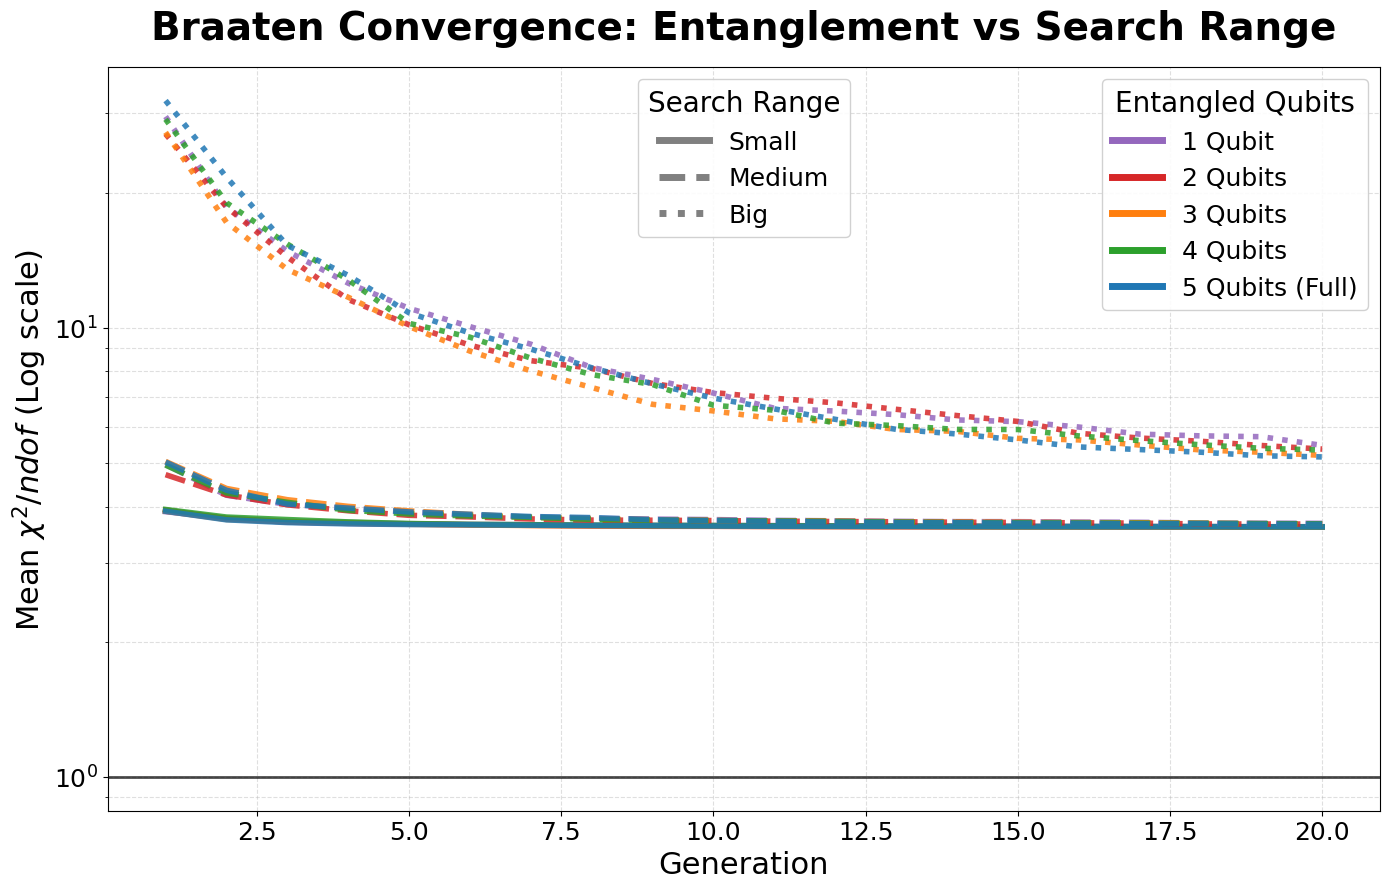

In [ ]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


entanglement_folders = {
    "1 Qubit": "resultados_tfm_2_1E",
    "2 Qubits": "resultados_tfm_2_2E",
    "3 Qubits": "resultados_tfm_2_PE",
    "4 Qubits": "resultados_tfm_2_4E",
    "5 Qubits (Full)": "resultados_tfm"
}

entanglement_colors = {
    "1 Qubit": '#9467bd',       
    "2 Qubits": '#d62728',      
    "3 Qubits": '#ff7f0e',      
    "4 Qubits": '#2ca02c',      
    "5 Qubits (Full)": '#1f77b4' 
}

range_styles = {
    "Small": "-",       
    "Medium": "--",     
    "Big": ":"          
}

model_target = "Braaten"
ranges = ["Small", "Medium", "Big"]
MAX_GENS = 20
N_PARAMS = 2

ndof = len(z_data) - N_PARAMS 


def process_chi2_history(raw_history, max_gens=20):
    padded_matrix = []
    for run in raw_history:
        if isinstance(run, (list, np.ndarray)):
            arr = list(run)
            if 0 < len(arr) < max_gens:
                arr.extend([arr[-1]] * (max_gens - len(arr)))
            elif len(arr) == 0:
                continue 
            padded_matrix.append(arr[:max_gens])
            
    if padded_matrix:
        return np.mean(np.array(padded_matrix), axis=0)
    else:
        return np.full(max_gens, np.nan)


generations_x_axis = np.arange(1, MAX_GENS + 1)

plt.figure(figsize=(14, 9))
ax = plt.gca()
drawn_curves = 0

for range_size, style in range_styles.items():
    for label, folder in entanglement_folders.items():
        filepath = f"{folder}/resultados_{model_target}_{range_size}.pkl"
        
        if not os.path.exists(filepath):
            print(f" Missing data for: {filepath}")
            continue
            
        with open(filepath, 'rb') as f:
            results = pickle.load(f)
            
        qga_data = results.get('qga', results.get('QGA', {}))
        if not qga_data or 'history' not in qga_data:
            continue
            
        raw_history = qga_data['history']
        mean_chi2_gen = process_chi2_history(raw_history, MAX_GENS)
        mean_chi2_ndof_gen = mean_chi2_gen / ndof
        
        ax.plot(generations_x_axis, mean_chi2_ndof_gen, 
                color=entanglement_colors[label], linestyle=style, 
                lw=4.0, alpha=0.85)
        drawn_curves += 1

if drawn_curves > 0:
    ax.set_yscale('log')
    ax.set_title(f'{model_target} Convergence: Entanglement vs Search Range', 
                 fontsize=28, fontweight='bold', pad=20)
    ax.set_xlabel('Generation', fontsize=22)
    ax.set_ylabel(r'Mean $\chi^2/ndof$ (Log scale)', fontsize=22)
    ax.tick_params(axis='both', which='major', labelsize=18)
    ax.grid(True, which="both", ls="--", alpha=0.4)
    
    ax.axhline(y=1.0, color='black', linestyle='-', lw=2.0, alpha=0.7, label='Ideal Fit ($\chi^2/ndof=1$)')
    
    entanglement_elements = [Line2D([0], [0], color=c, lw=5, label=l) for l, c in entanglement_colors.items()]
    range_elements = [Line2D([0], [0], color='gray', lw=5, linestyle=s, label=l) for l, s in range_styles.items()]
    
    ent_legend = ax.legend(handles=entanglement_elements, loc='upper right', 
                           fontsize=18, title='Entangled Qubits', title_fontsize=20, 
                           framealpha=0.9)
    ax.add_artist(ent_legend)
    
    range_legend = ax.legend(handles=range_elements, loc='upper center', 
                             fontsize=18, title='Search Range', title_fontsize=20, 
                             framealpha=0.9)
    
    ax.plot([], [], color='black', linestyle='-', lw=2.0, alpha=0.7, label='Ideal Fit ($\chi^2/ndof=1$)')
    
    plt.tight_layout()
    plt.show()
else:
    print(" No data was drawn. Please verify the folder paths and model names.")

Entanglement VS performance (data tables)

In [ ]:
import os
import pickle
import numpy as np
import pandas as pd
from scipy.stats import norm
from scipy.optimize import minimize


entanglement_folders = {
    "1 Qubit": "resultados_tfm_2_1E",
    "2 Qubits": "resultados_tfm_2_2E",
    "3 Qubits": "resultados_tfm_2_PE",
    "4 Qubits": "resultados_tfm_2_4E",
    "5 Qubits (Full)": "resultados_tfm"
}

models_info = {
    "Braaten": {
        "func": Braaten, "labels": ['N', r'$r$'],
        "ranges": {
            "Big":    {"min": [0.01, 0.01],  "max": [1.0, 1.0]},
            "Medium": {"min": [0.41, 0.175], "max": [0.61, 0.375]},
            "Small":  {"min": [0.46, 0.225], "max": [0.56, 0.325]}
        }
    },
    "Collins_Spiller": {
        "func": collins_spiller, "labels": ['N', r'$\epsilon_b$'],
        "ranges": {
            "Big":    {"min": [0.1, 0.0],   "max": [1.2, 0.2]},
            "Medium": {"min": [0.57, 0.03], "max": [0.77, 0.07]},
            "Small":  {"min": [0.62, 0.04], "max": [0.72, 0.06]}
        }
    },
    "Peterson": {
        "func": Peterson, "labels": ['N', r'$\epsilon_b$'],
        "ranges": {
            "Big":    {"min": [0.001, 0.0],    "max": [1.0, 0.3]},
            "Medium": {"min": [0.338, 0.0170], "max": [0.538, 0.0570]},
            "Small":  {"min": [0.388, 0.0270], "max": [0.488, 0.0470]}
        }
    }
}

MAX_GENS = 20
rangos_a_evaluar = ["Small", "Medium", "Big"]


def get_gens_to_target(history_matrix, threshold, max_gens):
    gens_array = []
    for run_hist in history_matrix:
        reached = False
        if not isinstance(run_hist, (list, np.ndarray)) or len(run_hist) == 0:
            gens_array.append(max_gens)
            continue
            
        for gen, val in enumerate(run_hist):
            if val <= threshold:
                gens_array.append(gen + 1)
                reached = True
                break
        if not reached:
            gens_array.append(max_gens)
    return np.array(gens_array)


table_data = []

for model_name, info in models_info.items():
    for current_range in rangos_a_evaluar:
        
        PARAM_MIN = np.array(info["ranges"][current_range]["min"])
        PARAM_MAX = np.array(info["ranges"][current_range]["max"])
        
        def chi2_dinamico(theta):
            if theta[0] <= 0: return 1e12
            y_fit = info["func"](z_data, *theta)
            chi2 = float(np.sum(((y_fit - y_data) / sigma_data)**2))
            return chi2 if np.isfinite(chi2) else 1e12

        def neg_chi2_dinamico(theta):
            return -chi2_dinamico(theta)
            
        x0_dinamico = (PARAM_MIN + PARAM_MAX) / 2.0
        
        res_min = minimize(chi2_dinamico, x0=x0_dinamico, bounds=list(zip(PARAM_MIN, PARAM_MAX)), method='L-BFGS-B')
        C_min = res_min.fun
        
        res_max = minimize(neg_chi2_dinamico, x0=x0_dinamico, bounds=list(zip(PARAM_MIN, PARAM_MAX)), method='L-BFGS-B')
        C_max = -res_max.fun
        
        chi2_acceptable = C_min + 2.3 
        
        for qubits_label, folder in entanglement_folders.items():
            filepath = f"{folder}/resultados_{model_name}_{current_range}.pkl"
            
            if not os.path.exists(filepath):
                continue 
                
            with open(filepath, 'rb') as f:
                results = pickle.load(f)
                
            qga_key = 'qga' if 'qga' in results else 'QGA'
            if qga_key not in results: continue
            
            chi2_array = np.array(results[qga_key].get('best_chi2', results[qga_key].get('chi2', [])))
            history = results[qga_key].get('history', [])
            n_runs = len(chi2_array)
            
            if n_runs == 0: continue
            
            if 'gens_to_target' in results[qga_key]:
                gens_array = np.array(results[qga_key]['gens_to_target'])
            elif len(history) > 0:
                gens_array = get_gens_to_target(history, chi2_acceptable, MAX_GENS)
            else:
                gens_array = np.full(n_runs, MAX_GENS)
            
            success_mask = chi2_array <= chi2_acceptable
            sp = np.sum(success_mask) / n_runs
            avg_gens = np.mean(gens_array[success_mask]) if np.sum(success_mask) > 0 else MAX_GENS
            
            ar_array = np.clip((C_max - chi2_array) / (C_max - C_min), 0, 1)
            mean_ar = np.mean(ar_array)
            
            table_data.append({
                "Model": model_name.replace("_", "-"),
                "Range": current_range,
                "Entanglement": qubits_label,
                "SP (%)": f"{sp*100:.1f}",
                "Mean A.R.": f"{mean_ar:.4f}",
                "Avg Gen": f"{avg_gens:.2f}"
            })


df_results = pd.DataFrame(table_data)

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("\n" + "="*80)
print(" RENDIMIENTO FÍSICO DEL HQGA SEGÚN GRADO DE ENTRELAZAMIENTO")
print("="*80)
print(df_results.to_string(index=False))
print("="*80)


 RENDIMIENTO FÍSICO DEL HQGA SEGÚN GRADO DE ENTRELAZAMIENTO
          Model  Range    Entanglement SP (%) Mean A.R. Avg Gen
        Braaten  Small         1 Qubit  100.0    0.9964    4.01
        Braaten  Small        2 Qubits  100.0    0.9975    3.19
        Braaten  Small        3 Qubits  100.0    0.9972    3.49
        Braaten  Small        4 Qubits  100.0    0.9968    4.44
        Braaten  Small 5 Qubits (Full)   99.0    0.9970    3.08
        Braaten Medium         1 Qubit   78.0    0.9971    7.82
        Braaten Medium        2 Qubits   82.0    0.9975    7.45
        Braaten Medium        3 Qubits   78.0    0.9974    8.24
        Braaten Medium        4 Qubits   82.0    0.9974    8.05
        Braaten Medium 5 Qubits (Full)   83.0    0.9977    8.35
        Braaten    Big         1 Qubit    0.0    0.9951   20.00
        Braaten    Big        2 Qubits    0.0    0.9954   20.00
        Braaten    Big        3 Qubits    0.0    0.9958   20.00
        Braaten    Big        4 Qubits    0

HQGA VS CGA (poster plot)

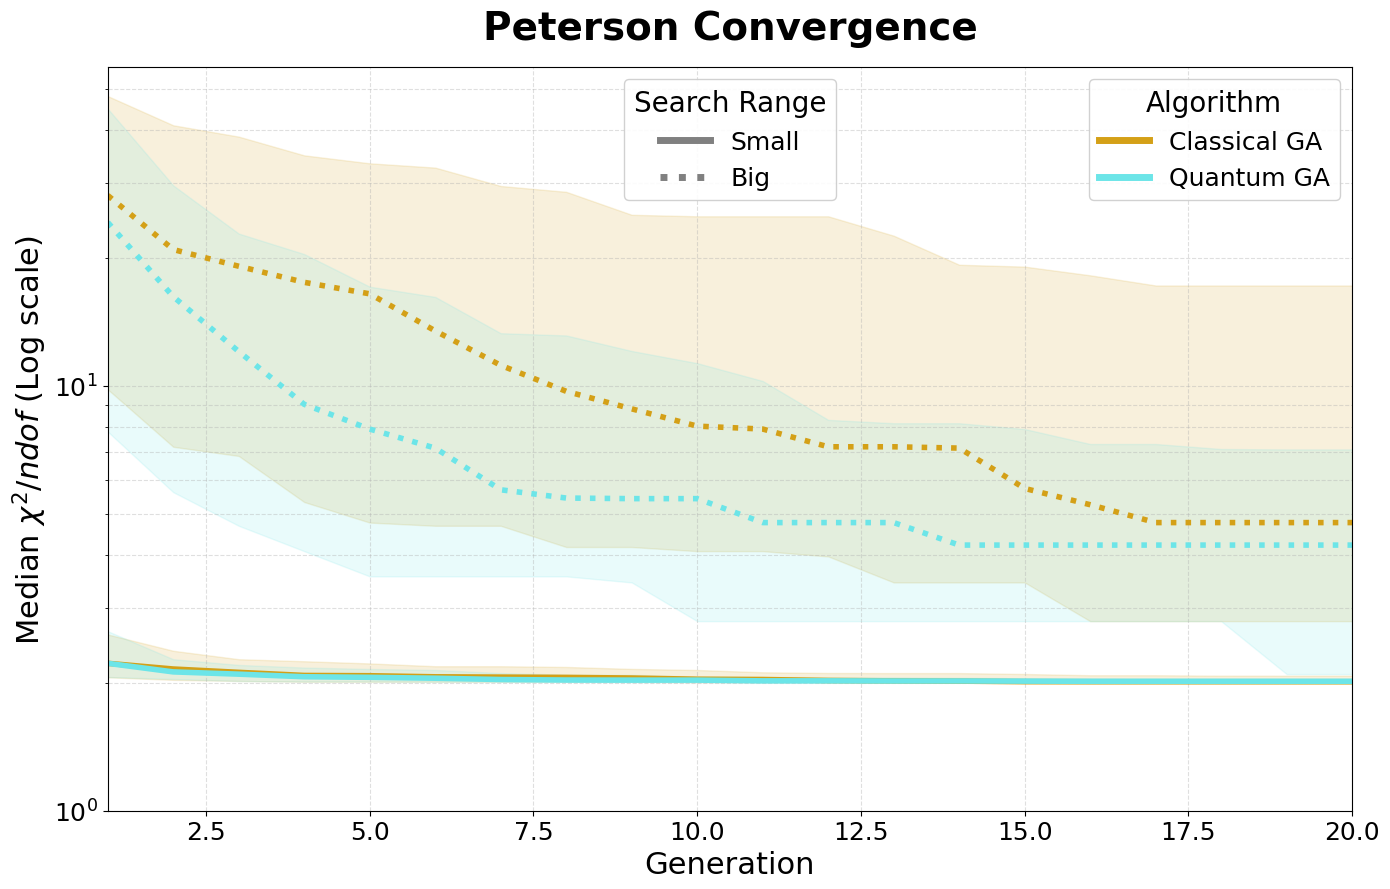

In [ ]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


model_target = "Peterson"        
folder_target = "resultados_tfm" 
MAX_GENS = 20
N_PARAMS = 2 

try:
    ndof = len(z_data) - N_PARAMS
except NameError:
    ndof = 10 


def process_chi2_history(raw_history, max_gens=20):
    padded_matrix = []
    for run in raw_history:
        if isinstance(run, (list, np.ndarray)):
            arr = list(run)
            if 0 < len(arr) < max_gens:
                arr.extend([arr[-1]] * (max_gens - len(arr)))
            elif len(arr) == 0:
                continue 
            padded_matrix.append(arr[:max_gens])
            
    if padded_matrix:
        mat = np.array(padded_matrix)
        mediana = np.median(mat, axis=0)
        p_low = np.percentile(mat, 15, axis=0)  
        p_high = np.percentile(mat, 85, axis=0) 
        return mediana, p_low, p_high
    else:
        return np.full(max_gens, np.nan), np.full(max_gens, np.nan), np.full(max_gens, np.nan)


generaciones = np.arange(1, MAX_GENS + 1)
plt.figure(figsize=(14, 9))
ax = plt.gca()

ranges_config = {
    "Small": "-",       
    "Big": ":"          
}

algo_config = {
    'cga': {'label': 'Classical GA', 'color': '#D4A017'},
    'qga': {'label': 'Quantum GA', 'color': '#6CE5E8'}
}

curvas_dibujadas = 0

for range_name, linestyle in ranges_config.items():
    filepath = f"{folder_target}/resultados_{model_target}_{range_name}.pkl"
    
    if not os.path.exists(filepath):
        print(f" Missing data for: {filepath}")
        continue
        
    with open(filepath, 'rb') as f:
        results = pickle.load(f)

    for algo_key, settings in algo_config.items():
        real_key = algo_key if algo_key in results else algo_key.upper()
        
        if real_key not in results or 'history' not in results[real_key]:
            continue
            
        raw_history = results[real_key]['history']
        
        mediana_chi2, p_low_chi2, p_high_chi2 = process_chi2_history(raw_history, MAX_GENS)
        
        mediana_ndof = mediana_chi2 / ndof
        p_low_ndof = p_low_chi2 / ndof
        p_high_ndof = p_high_chi2 / ndof
        
        ax.plot(generaciones, mediana_ndof, color=settings['color'], 
                lw=4, linestyle=linestyle)
        
        ax.fill_between(generaciones, p_low_ndof, p_high_ndof, 
                        color=settings['color'], alpha=0.15)
        
        curvas_dibujadas += 1


if curvas_dibujadas > 0:
    ax.set_yscale('log')
    ax.set_title(f'{model_target.replace("_", " ")} Convergence', 
                 fontsize=28, fontweight='bold', pad=20)
    ax.set_xlabel('Generation', fontsize=22)
    ax.set_ylabel(r'Median $\chi^2/ndof$ (Log scale)', fontsize=22)
    
    ax.tick_params(axis='both', which='major', labelsize=18)
    ax.grid(True, which="both", ls="--", alpha=0.4)
    
    ax.set_xlim(1, MAX_GENS)
    ax.set_ylim(bottom=1.0) 
    
    algo_elements = [Line2D([0], [0], color=s['color'], lw=5, label=s['label']) for k, s in algo_config.items()]
    range_elements = [Line2D([0], [0], color='gray', lw=5, linestyle=ls, label=r) for r, ls in ranges_config.items()]
    
    algo_legend = ax.legend(handles=algo_elements, loc='upper right', 
                            fontsize=18, title='Algorithm', title_fontsize=20, 
                            framealpha=0.9)
    ax.add_artist(algo_legend)
    
    range_legend = ax.legend(handles=range_elements, loc='upper center', 
                             fontsize=18, title='Search Range', title_fontsize=20, 
                             framealpha=0.9)

    plt.tight_layout()
    plt.show()

Entanglement 3 param poster plot

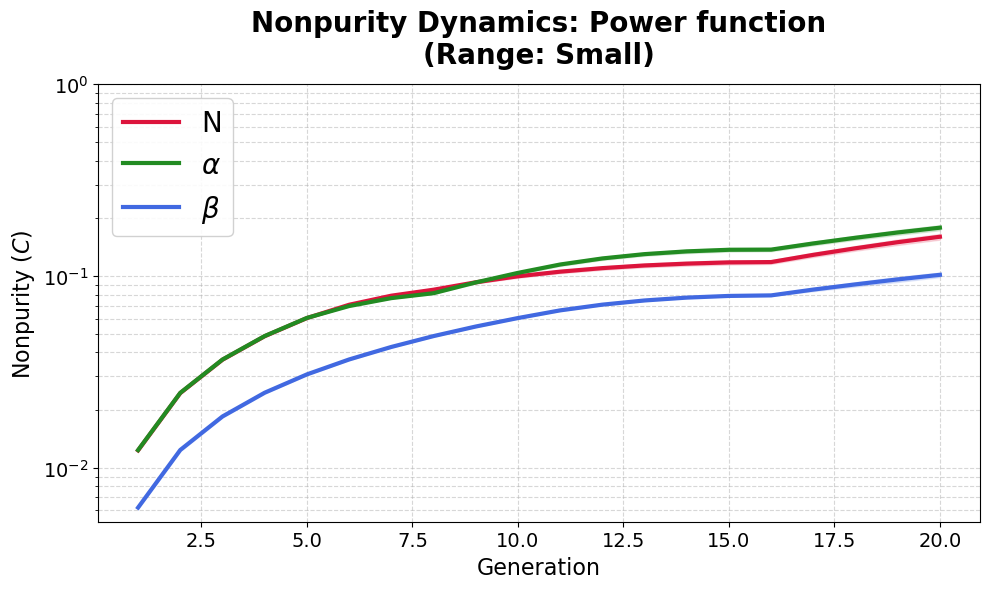

In [ ]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt


directorio_3p = "resultados_tfm_3params"
modelo_objetivo = "Power_function"  
rango_objetivo = "Small"        

etiquetas_parametros = {
    "Peterson_modified": ['N', r'$\epsilon_b$', r'$\alpha$'],
    "Lund_group":        ['N', r'$a$', r'$b$'],
    "Bowler":            ['N', r'$a$', r'$b$'],
    "Power_function":    ['N', r'$\alpha$', r'$\beta$'],
    "F1":                ['N', r'$c$', r'$d$'],
    "F2":                ['N', r'$c$', r'$d$']
}

etiquetas = etiquetas_parametros.get(modelo_objetivo, ['Param 1', 'Param 2', 'Param 3'])
colores = ['crimson', 'forestgreen', 'royalblue']


filepath = os.path.join(directorio_3p, f"resultados_{modelo_objetivo}_{rango_objetivo}.pkl")

dict_datos = {"C_p1": [], "C_p2": [], "C_p3": []}

if not os.path.exists(filepath):
    print(f" No se encuentra el archivo {filepath}")
else:
    with open(filepath, 'rb') as f:
        datos = pickle.load(f)
        qga_data = datos.get('qga', {})
        
        if "C_p1" in qga_data:
            dict_datos["C_p1"].extend(qga_data["C_p1"])
            dict_datos["C_p2"].extend(qga_data["C_p2"])
            dict_datos["C_p3"].extend(qga_data["C_p3"])
        else:
            print("No se encontraron datos de impureza (C_p1, C_p2, C_p3) en este archivo.")

    
    c1_array = np.array(dict_datos["C_p1"])
    c2_array = np.array(dict_datos["C_p2"])
    c3_array = np.array(dict_datos["C_p3"])

    if c1_array.size > 0:
        media_c1 = np.mean(c1_array, axis=0)
        media_c2 = np.mean(c2_array, axis=0)
        media_c3 = np.mean(c3_array, axis=0)
        
        std_c1 = np.std(c1_array, axis=0)
        std_c2 = np.std(c2_array, axis=0)
        std_c3 = np.std(c3_array, axis=0)
        
        generaciones = np.arange(1, len(media_c1) + 1)
        
        plt.figure(figsize=(10, 6))
        ax = plt.gca()
        
        ax.plot(generaciones, media_c1, label=etiquetas[0], color=colores[0], lw=3)
        ax.plot(generaciones, media_c2, label=etiquetas[1], color=colores[1], lw=3)
        ax.plot(generaciones, media_c3, label=etiquetas[2], color=colores[2], lw=3)
        
        ax.fill_between(generaciones, np.clip(media_c1 - std_c1, 1e-5, None), media_c1 + std_c1, color=colores[0], alpha=0.15)
        ax.fill_between(generaciones, np.clip(media_c2 - std_c2, 1e-5, None), media_c2 + std_c2, color=colores[1], alpha=0.15)
        ax.fill_between(generaciones, np.clip(media_c3 - std_c3, 1e-5, None), media_c3 + std_c3, color=colores[2], alpha=0.15)
        
        ax.set_title(f"Nonpurity Dynamics: {modelo_objetivo.replace('_', ' ')}\n(Range: {rango_objetivo})", 
                     fontsize=20, fontweight='bold', pad=15)
        ax.set_xlabel('Generation', fontsize=16)
        ax.set_ylabel('Nonpurity ($C$)', fontsize=16)
        
        ax.set_yscale('log')
        ax.set_yticks([10**0, 10**-1, 10**-2])
        ax.tick_params(axis='both', which='major', labelsize=14)
        ax.grid(True, which="both", ls="--", alpha=0.5)
        
        ax.legend(fontsize=20, loc='upper left', framealpha=0.9)
        
        plt.tight_layout()
        plt.show()
    else:
        print(" El array de datos está vacío.")

Entanglement 2 param poster plot

✅ Claves de impureza detectadas: C_N y C_param2


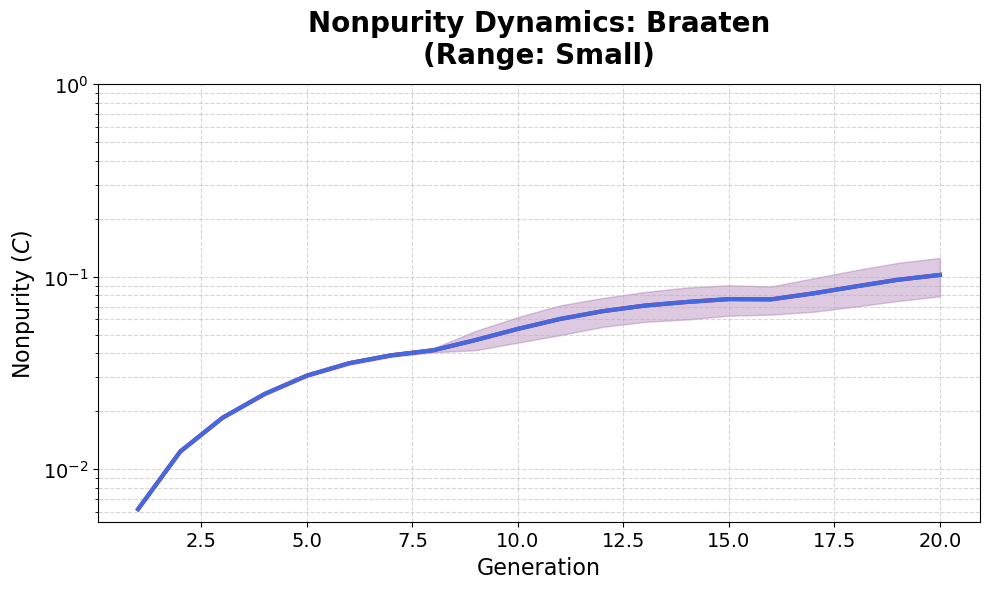

In [ ]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt


directorio_2p = "resultados_tfm"
modelo_objetivo = "Braaten" 
rango_objetivo = "Small"      

etiquetas_parametros = {
    "Braaten":         ['N', r'$r$'],
    "Collins_Spiller": ['N', r'$\epsilon_b$'],
    "Kartvelishvili":  ['N', r'$\alpha_b$'],
    "Peterson":        ['N', r'$\epsilon_b$']
}

etiquetas = etiquetas_parametros.get(modelo_objetivo, ['Param 1', 'Param 2'])
colores = ['crimson', 'royalblue'] 


filepath = os.path.join(directorio_2p, f"resultados_{modelo_objetivo}_{rango_objetivo}.pkl")

dict_datos = {"C_p1": [], "C_p2": []}

if not os.path.exists(filepath):
    print(f" No se encuentra el archivo {filepath}")
else:
    with open(filepath, 'rb') as f:
        datos = pickle.load(f)
        qga_data = datos.get('qga', {})
        
        claves_C = sorted([k for k in qga_data.keys() if ('C_' in k or 'c_' in k.lower() or 'historial' in k.lower()) 
                           and k not in ['chi2', 'gens_to_target', 'history', 'best_binary', 'best_theta', 'best_chi2']
                           and isinstance(qga_data[k], (list, np.ndarray)) and len(qga_data[k]) > 0])
        
        if len(claves_C) >= 2:
            print(f" Claves de impureza detectadas: {claves_C[0]} y {claves_C[1]}")
            dict_datos["C_p1"].extend(qga_data[claves_C[0]])
            dict_datos["C_p2"].extend(qga_data[claves_C[1]])
        else:
            print("No se encontraron 2 historiales de impureza válidos.")
            print(f"Claves disponibles en el diccionario: {list(qga_data.keys())}")

   
    c1_array = np.array(dict_datos["C_p1"])
    c2_array = np.array(dict_datos["C_p2"])

    if c1_array.size > 0:
        media_c1 = np.mean(c1_array, axis=0)
        media_c2 = np.mean(c2_array, axis=0)
        
        std_c1 = np.std(c1_array, axis=0)
        std_c2 = np.std(c2_array, axis=0)
        
        generaciones = np.arange(1, len(media_c1) + 1)
        
        plt.figure(figsize=(10, 6))
        ax = plt.gca()
        
        ax.plot(generaciones, media_c1, label=f"Parameter 1 ({etiquetas[0]})", color=colores[0], lw=3)
        ax.plot(generaciones, media_c2, label=f"Parameter 2 ({etiquetas[1]})", color=colores[1], lw=3)
        
        ax.fill_between(generaciones, np.clip(media_c1 - std_c1, 1e-5, None), media_c1 + std_c1, color=colores[0], alpha=0.15)
        ax.fill_between(generaciones, np.clip(media_c2 - std_c2, 1e-5, None), media_c2 + std_c2, color=colores[1], alpha=0.15)
        
        ax.set_title(f"Nonpurity Dynamics: {modelo_objetivo.replace('_', ' ')}\n(Range: {rango_objetivo})", 
                     fontsize=20, fontweight='bold', pad=15)
        ax.set_xlabel('Generation', fontsize=16)
        ax.set_ylabel('Nonpurity ($C$)', fontsize=16)
        
        ax.set_yscale('log')
        ax.set_yticks([10**0, 10**-1, 10**-2])
        ax.tick_params(axis='both', which='major', labelsize=14)
        ax.grid(True, which="both", ls="--", alpha=0.5)
        
        
        plt.tight_layout()
        plt.show()
    else:
        print(" El array de datos está vacío.")